<a href="https://colab.research.google.com/github/realtommypoole/LLMRAGOptimize/blob/Dev-Branch/AAI_590_20260406_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Title: LLM RAG Distillation & Supervised Fine Tuning Optimization
## Subtitle: Fine tuning open source nano models with larger reasoning models
Author: Tommy Poole, Spring Semester 2026, University of San Diego, Shirley Marcos School of Engineering, Master's in Science of Applied Artificial Intelligence

**Attribution:** Claude code March 29. Perplexity March 29. Microsoft for contextual.





---



In [1]:
"""
# ============================================================
# COLAB DISK + MEMORY CLEAR — Complete Reset
# ============================================================

import gc
import torch
import os
import shutil
from IPython.display import clear_output

print("🗑️  Clearing Colab DISK + MEMORY...")

# === 1. MEMORY CLEAR (from previous answer) ===
large_objects = ['all_inference_results', 'all_eval_results', 'ft_model_dirs',
                 'test_pairs', 'train_splits', 'summary_df']
for obj_name in large_objects:
    if obj_name in globals():
        del globals()[obj_name]

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
gc.collect()

# === 2. DISK CLEANUP ===
print("\n🧹 Clearing disk space...")

# A. Delete common temp directories
temp_dirs = [
    "/tmp/*",
    "/root/.cache/huggingface/*",
    "/root/.cache/torch/*",
    "/content/sample_data/*"
]
for pattern in temp_dirs:
    os.system(f"rm -rf {pattern}")
    print(f"  🗑️  Cleared {pattern}")

# B. Hugging Face cache (models/tokenizers)
os.system("rm -rf /root/.cache/huggingface/hub/models--*")
print("  🗑️  HF model cache")

# C. Colab temp files
os.system("rm -rf /content/models/* /content/data/*")  # Adjust paths!
print("  🗑️  Colab temp files")

# D. Google Drive cache (if mounted)
if os.path.exists("/content/drive"):
    os.system("rm -rf /root/.config/Google/DriveFS")
    print("  🗑️  DriveFS cache")

# E. Linux page cache + sync
os.system("sync && echo 3 > /proc/sys/vm/drop_caches")
print("  🗑️  System page cache")

# === 3. VERIFY DISK SPACE ===
!df -h /content
print("\n✅ Disk + Memory cleared!")
clear_output(wait=True)


SyntaxError: incomplete input (2817624080.py, line 1)

## Introduction

Retreival Augmented Generation (RAG) helps Large Language Models perform when applied to contexts with specific knowledge, such as enterprise business settings. RAG solutions produce more accurate information by gounding generated answers in a corpus of specific knowledge, vocuabluary, and even way of writing. One way this kind of application can be optimized to produce better answers is with supervised fine tuning, where specific information is used to update weights on the original LLM. This fine tuning, coupled with RAG, can achieve even better results than RAG alone. One of the key questions is exactly how much better this approach can make results.

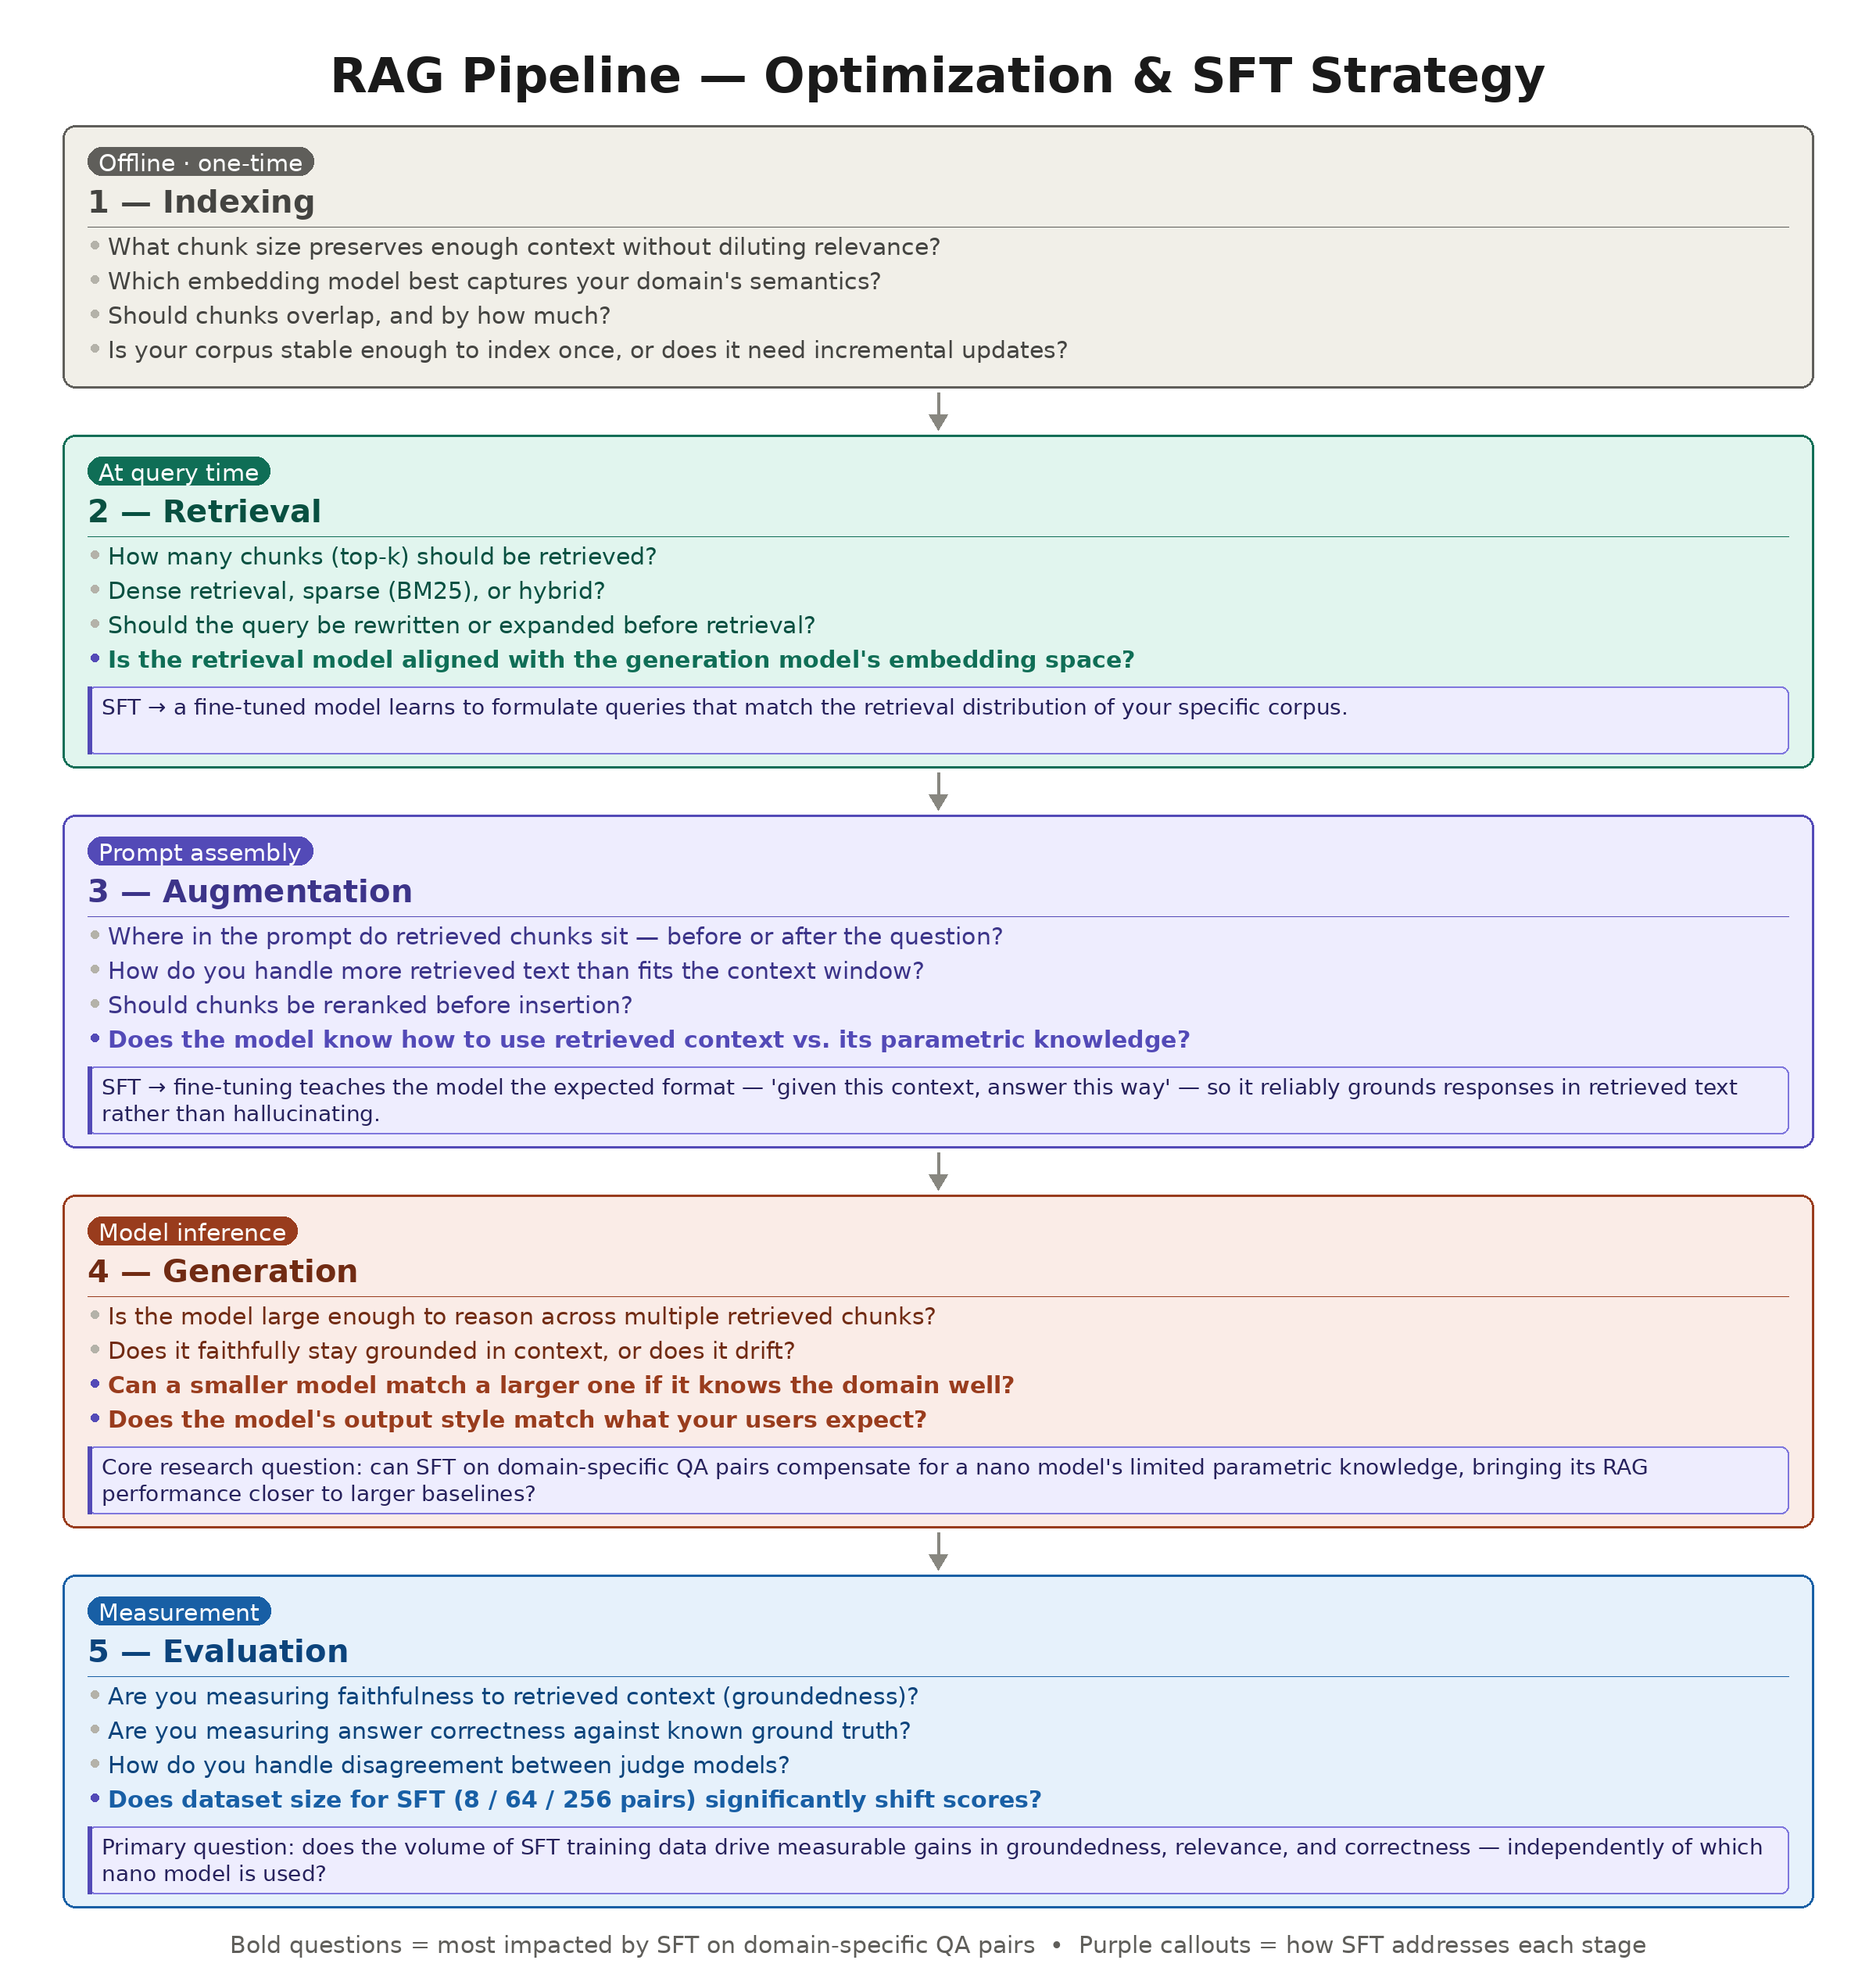

This project compares fine tuning with different amounts of data across different models. Both agents have access to the same data for reference, but one of them has been fine-tuned with supervised fine tuning on a curated set of question answer pairs. The code is outlined as follows:

1. Import key libraries.
2. Download models from HuggingFace
  - Medium Sized Models (Qwen3-8B, gemma-4-26B-A4B-it, Meta Llama-3-8B-Instruct, DeepSeek-R1-Distill-Qwen-14B )
  - Nano Models (SmolLM3-3B, Nemotron 3 Nano-4B, Llama-3.2-1B-Instruct)
  - Connect API to Claude 4.6 for comparison
3. Upload or ingest a corpus of data.
4. Generate text embeddings, store in vector store.
5. Use largers models to create question answer pairs each based on the corpus, convert to JSONL format and combine in one dataset.
6. Create four datasets from those total questions of QA pairs for fine tuning of the following sizes: (40 held out as test), then 256 QA pairs, 64 QA pairs, and 8 QA pairs.
7. Train: Fine tune all three nano models with the question answer pairs of varying sized sets.
8. RAG Inference v. Fine Tuned: Generate responses with trained models, and base models: Generate responses to the 40 test questions with the three fine tuned models, and all three non fine tuned models base nano, with the same prompt and corpus for reitreival. Also test larger models, and frontier model against same questions.
9. Evaluate: Use multi-model ensamble to evaluate each response against the ground truth for groundedness, relevance, and correctness based on Microsoft documentation to determine scales (1-5) to match their CoPilot studio evaluation metrics. Two models score each question on all metrics, then average results.
10. Visualize results.
11. Discuss results. The primary question for evaluation is whether or not the total number of questions used impacts the fine tuning results. Different nano models are used to ensure it isn't an issue with the nano model selected, but evaluation of QA dataset size can average across each nano model assuming they aren't significantly different.

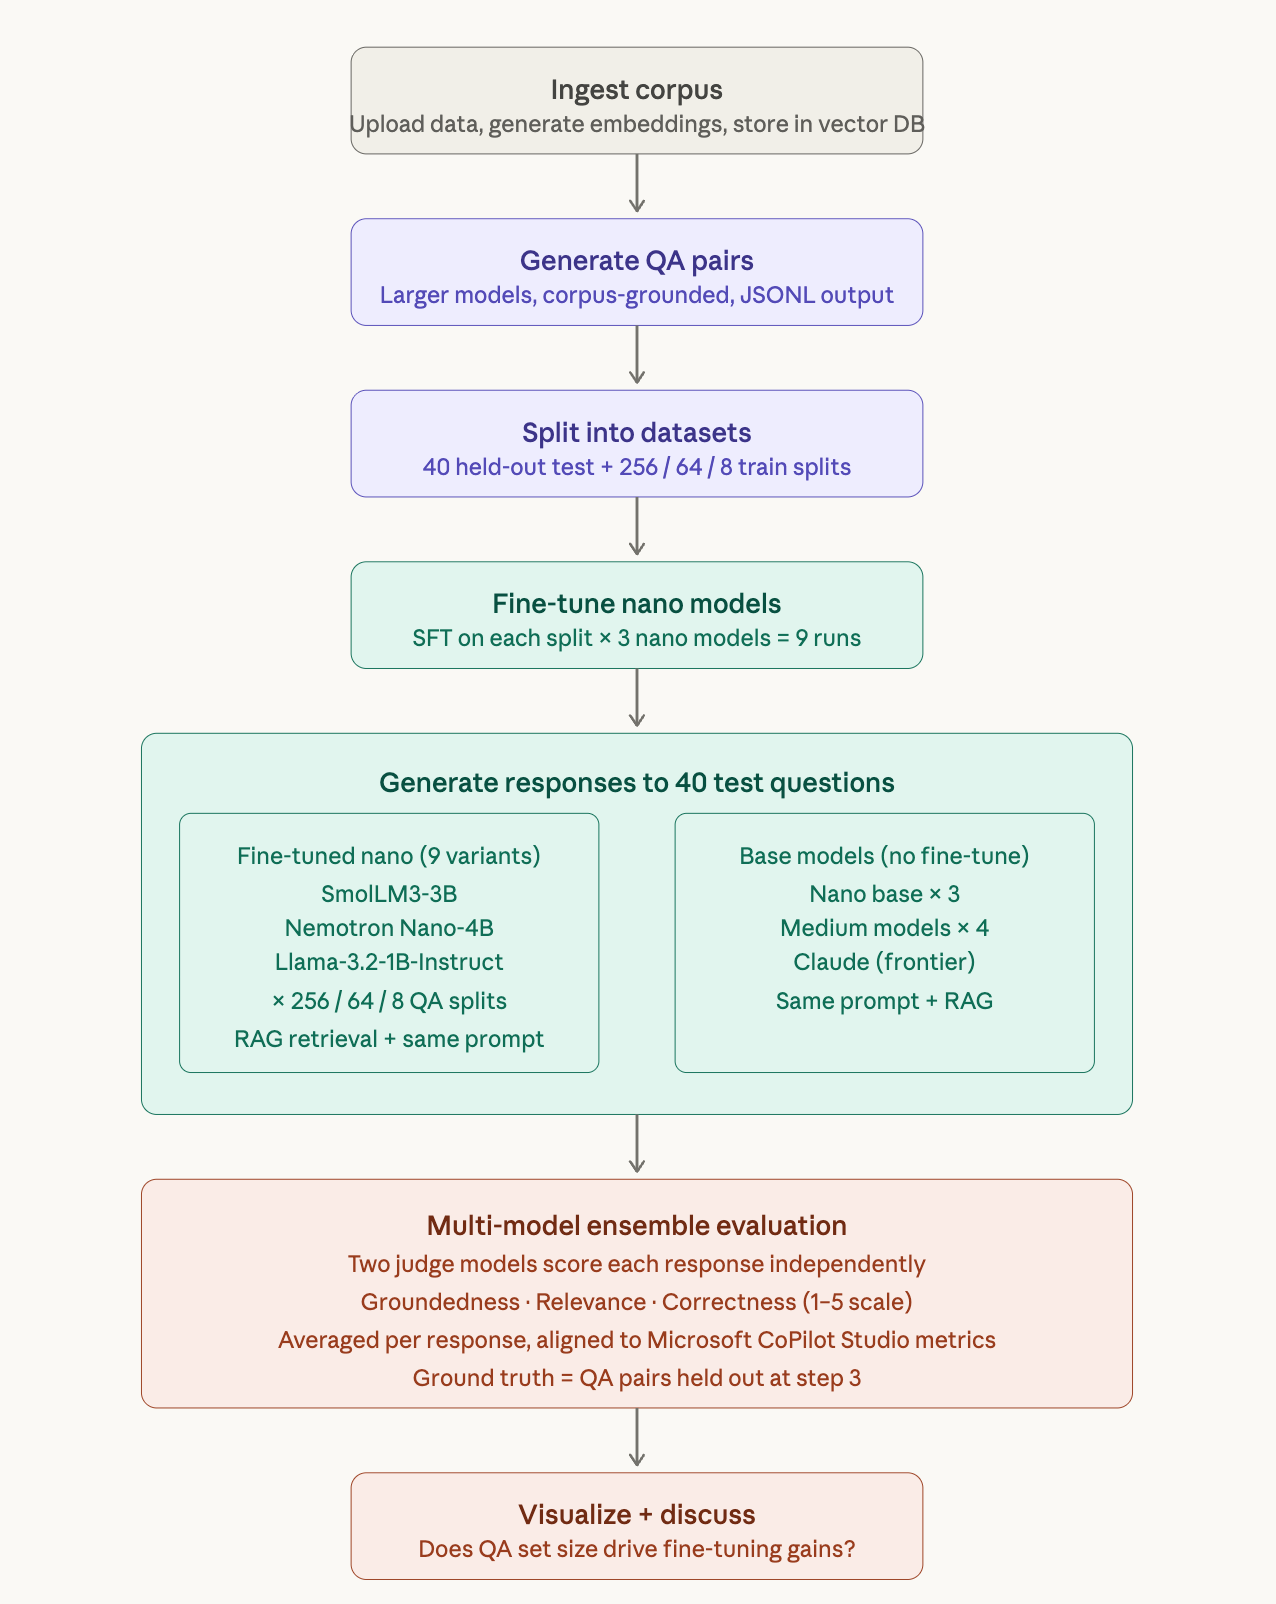

# 1. Import Libraries

**NOTE:** If using Google CoLab, connect to GPU with High Ram.

In [8]:
# Install dependencies (run once)
!pip install transformers datasets huggingface_hub peft trl accelerate bitsandbytes
!pip install sentence-transformers faiss-cpu
!pip install anthropic
!pip install jsonlines tqdm
!pip install pypdf
!pip install matplotlib seaborn
!pip install -q -U google-generativeai
!pip install pdfplumber pymupdf
!pip install --upgrade transformers accelerate bitsandbytes optimum

In [39]:
# Standard Library
import os
import json
import re
from pathlib import Path
import sklearn
from sklearn.model_selection import train_test_split
import pypdf
import random, time
from peft import PeftModel
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from math import pi
import pdfplumber
import fitz

# Third-party: data & numerics
import numpy as np
import pandas as pd
from tqdm import tqdm
import jsonlines
import gc
import hashlib

# PyTorch
import torch

# HuggingFace: models, tokenizers, datasets
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    pipeline,
)
from datasets import Dataset, load_dataset
from huggingface_hub import login as hf_login

# HuggingFace: fine-tuning (PEFT / SFT)
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig

# Embeddings & vector store
from sentence_transformers import SentenceTransformer
import faiss

# Anthropic (Claude)
import anthropic

# Gemini
from google import genai
from google.genai import types

# Google CoLab
from google.colab import userdata

# Sanity check (print for check)
print(f"PyTorch version : {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU name   : {torch.cuda.get_device_name(0)}")


import warnings
warnings.filterwarnings(
    "ignore",
    message=r".*Both `max_new_tokens`.*and `max_length`.*"
)

PyTorch version : 2.10.0+cu128
Using device: cuda
GPU name   : NVIDIA RTX PRO 6000 Blackwell Server Edition


# 2. Model Setup & API Connections

In [10]:
# API Keys
HF_TOKEN      = userdata.get("HF_TOKEN")
ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_KEY")
GEMINI_API_KEY    = userdata.get("GEMINI")

# --- Reasoning Models (QA generation + baseline inference) ---
REASONING_MODELS = {
    "qwen"     : "Qwen/Qwen3-8B",    # Issues with larger thinking model output format, used smaller model
    "gemma"    : "google/gemma-4-26B-A4B-it", # released early April, 2026
    "deepseek" : "deepseek-ai/DeepSeek-R1-Distill-Qwen-14B", # specifically high rank on RAG
    "llama"    : "meta-llama/Meta-Llama-3-8B-Instruct", # fourth option for review
}

# --- Nano Models (fine-tune targets) ---
NANO_MODELS = {
    "smollm"   : "HuggingFaceTB/SmolLM3-3B",
    "nemotron" : "nvidia/Nemotron-Mini-4B-Instruct",
    "llamaNano" : "meta-llama/Llama-3.2-1B-Instruct",
}

# LoRA target modules — override per model if architecture differs
LORA_TARGETS = {
    "smollm"   : ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    "nemotron" : ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    "llamaNano" : ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
}

# --- Dataset sizes for SFT comparison ---
DATASET_SIZES = [256, 64, 8]
NUM_TEST      = 40        # held-out questions (never used in training)

# --- Data Directories ---
DATASET_DIR   = Path("data") # filepath containing source PDFs
DATASET_DIR.mkdir(parents=True, exist_ok=True)

# Derived subdirectories — all cascade from DATASET_DIR
QA_DIR      = DATASET_DIR / "qa_outputs" # ./data/qa_outputs/
SPLITS_DIR  = DATASET_DIR / "qa_splits" # ./data/qa_splits/
MODELS_DIR  = DATASET_DIR / "models" # ./data/models/
RESULTS_DIR = DATASET_DIR / "results" # ./data/results/
EVAL_DIR    = DATASET_DIR / "eval" # ./data/eval/

# Create all directories
for d in [QA_DIR, SPLITS_DIR, MODELS_DIR, RESULTS_DIR, EVAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"\n\n\n--- 📁 Unified paths:")
print(f"  ROOT     : {DATASET_DIR}")
print(f"  QA       : {QA_DIR}")
print(f"  QA Splits: {SPLITS_DIR}")
print(f"  Models   : {MODELS_DIR}")
print(f"  Results  : {RESULTS_DIR}")
print(f"  Eval     : {EVAL_DIR}")

# --- API Connections ---
hf_login(token=HF_TOKEN)
print("\nHuggingFace login : OK")

# Claude
claude_client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)
CLAUDE_MODEL  = "claude-sonnet-4-6"
_ping = claude_client.messages.create(
    model=CLAUDE_MODEL, max_tokens=16,
    messages=[{"role": "user", "content": "Reply OK"}],
)
print(f"Claude connected  : {_ping.content[0].text.strip()}")

# --- Shared 4-bit quantization config ---
bnb_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    llm_int8_enable_fp32_cpu_offload=True,
    llm_int8_threshold=6.0,
)

print("\n✅ Config complete — models load on demand in later sections.")





--- 📁 Unified paths:
  ROOT     : data
  QA       : data/qa_outputs
  QA Splits: data/qa_splits
  Models   : data/models
  Results  : data/results
  Eval     : data/eval

HuggingFace login : OK
Claude connected  : OK

✅ Config complete — models load on demand in later sections.


# 3. Corpus Ingestion

Requires file(s) upload. Used key textbook for AAI Program as example.

Citation Needed:

In [11]:
# Config
CHUNK_SIZE    = 384 # scaled down from 512 to reduce noise in chunks
CHUNK_OVERLAP = 96 # overlapping char number, to preserve context


# Load chunks if already exist, don't duplicate below if able
def load_corpus_chunks(chunks_path: Path):
    if chunks_path.exists():
        with jsonlines.open(chunks_path) as f:
            chunks = list(f)
        print(f"✅ Loaded {len(chunks):,} saved chunks from {chunks_path}")
        return chunks
    return None

# --- PDF Text Extraction ---

# Use PDF Plumber for more robust text extraction, fail to fitz if pdfplumber fails
# *Returns* concatonated text with page markers
def extract_text_from_pdf(pdf_path: Path) -> str:
    text_parts = []
    try:
        with pdfplumber.open(str(pdf_path)) as pdf:
            num_pages = len(pdf.pages)
            print(f"  Extracting {pdf_path.name} ({num_pages:,} pages)...")
            for i, page in enumerate(pdf.pages):
                page_text = page.extract_text() or ""
                if page_text.strip():
                    text_parts.append(f"--- Page {i+1} ---\n{page_text}")
                page.flush_cache()
                if (i + 1) % 100 == 0:
                    print(f"    Page {i+1}/{num_pages}")
            full_text = "\n\n".join(text_parts)
            print(f"  {pdf_path.name}: {num_pages:,} pages → {len(full_text):,} chars")
            return full_text
    except Exception as e:
        print(f"  pdfplumber failed: {e}")

    # Secondary fallback to fitz (PyMuPDF)
    try:
        doc = fitz.open(str(pdf_path))
        num_pages = len(doc)
        print(f"  Falling back to PyMuPDF for {pdf_path.name} ({num_pages:,} pages)...")
        for i, page in enumerate(doc):
            page_text = page.get_text()
            if page_text.strip():
                text_parts.append(f"--- Page {i+1} ---\n{page_text}")
            if (i + 1) % 100 == 0:
                print(f"    Page {i+1}/{num_pages}")
        doc.close()
        full_text = "\n\n".join(text_parts)
        print(f"  {pdf_path.name}: {num_pages:,} pages → {len(full_text):,} chars")
        return full_text
    except Exception as e:
        print(f"  PyMuPDF failed: {e}")
        return f"[EXTRACTION FAILED: {pdf_path.name}]"


# --- Text Chunking ---

# Split extracted text into semantically cohesive chunks
# Handles paragraph boundaries, overlaps, and filters small chunks
def chunk_text(text: str, chunk_size: int = CHUNK_SIZE, overlap: int = CHUNK_OVERLAP) -> list[str]:
    paragraphs = re.split(r'\n\s*\n|\n#{1,3}\s', text)
    chunks = []

    # Split text using blank lines or headers as separators
    for para in paragraphs:
        para = para.strip()
        if not para:
            continue

        # If paragraph fits chunk size, keep as-is
        if len(para) <= chunk_size:
            chunks.append(para)
        else:
            # Otherwise, split with overlaping windoes to maintain semantic continuity
            start = 0
            while start < len(para):
                chunk = para[start:start + chunk_size].strip()
                if chunk:
                    chunks.append(chunk)
                start += chunk_size - overlap

    # Filter out very short fragments (they are likely noise)
    return [c for c in chunks if len(c) > 50]


# --- Corpus Assembly ---
chunks_file = DATASET_DIR / "corpus_chunks.jsonl"
corpus_chunks = load_corpus_chunks(chunks_file)

if corpus_chunks is None:

    # Locate PDF Files
    pdf_files = sorted(DATASET_DIR.glob("*.pdf"))
    assert pdf_files, f"No PDFs found in {DATASET_DIR.resolve()}"

    corpus_chunks = []

    # Extract and chunk each PDF
    for pdf_path in pdf_files:
        raw_text = extract_text_from_pdf(pdf_path)
        chunks = chunk_text(raw_text)
        for i, chunk in enumerate(chunks):
            corpus_chunks.append({
                "source": pdf_path.name,
                "chunk_id": i,
                "text": chunk
            })
        print(f"  → {len(chunks):,} chunks from {pdf_path.name}")

    # Save all generated chunks to disk
    with jsonlines.open(chunks_file, "w") as f:
        f.write_all(corpus_chunks)
    print(f"\n\n\n💾 Saved {len(corpus_chunks):,} chunks to {chunks_file}")


# --- Corpus Statistics ---

# Count tokens for overview of chunk size distribution
_count_tok = AutoTokenizer.from_pretrained(list(NANO_MODELS.values())[0], token=HF_TOKEN)
total_tokens = 0
total_chars = 0
for chunk in corpus_chunks:
    total_chars += len(chunk["text"])
    total_tokens += len(_count_tok(chunk["text"], add_special_tokens=False)["input_ids"])
del _count_tok

print(f"  Avg chunk tokens: {total_tokens / len(corpus_chunks):.0f}")

# Preview a few randomly sampled chunks for sanity check
samples = random.sample(corpus_chunks, min(5, len(corpus_chunks)))
print("\n\n\n=== 5 RANDOM CHUNK SAMPLES ===")
for i, chunk in enumerate(samples, 1):
    print(f"\n{i}. {chunk['source']} (chunk {chunk['chunk_id']})")
    print(f"   {repr(chunk['text'][:200])}...")

# Display overall corpus statistics
print(f"\n=== CORPUS SUMMARY ===")
print(f"  PDFs loaded   : {len(set(c['source'] for c in corpus_chunks))}")
print(f"  Total chunks  : {len(corpus_chunks):,}")
print(f"  Total chars   : {total_chars:,}")
print(f"  Total tokens  : {total_tokens:,}")

✅ Loaded 11,773 saved chunks from data/corpus_chunks.jsonl
  Avg chunk tokens: 102



=== 5 RANDOM CHUNK SAMPLES ===

1. Artificial Intelligence - A Modern Approach (3rd Edition).pdf (chunk 1376)
   'independently of\nthe others. In a local beam search, useful information is passed among the parallel search\nthreads. In effect, the states that generate the best successors say to the others, “Come ov'...

2. Artificial Intelligence - A Modern Approach (3rd Edition).pdf (chunk 9556)
   'gend that Marvin Minsky assigned the problem\nof“solving”computervisiontoagraduatestudentasasummerproject. AccordingtoMinsky\nthe legend is untrue—it was actually an undergraduate student. But it was an'...

3. Artificial Intelligence - A Modern Approach (3rd Edition).pdf (chunk 5055)
   'ibuted to Laplace, but he neverisolated\nINDIFFERENCE\nthe principle explicitly. George Boole and John Venn both referred to it as the principle of\nPRINCIPLEOF\ninsufficientreason;themodernnameisduetoKey'...

4. Artific

# 4. Embeddings & Vector Store

Retrieval setup, turning pre-chunked corpus into a searchable knowledge base using sentence embeddings and FAISS, Facebook AI Similarity Search for effecient similarity searching.

In [12]:
# Config
EMBED_MODEL_ID = "all-MiniLM-L6-v2"   # fast, reliable; can swap for larger model if needed, creates 384-dimensional embeddigns
TOP_K          = 5                     # default chunks to retrieve per query

# --- Model Loading ---
# Load embedding model, SentenceTransformer, maps text chunks or queries into dense vector embeddings
print(f"Loading embedding model: {EMBED_MODEL_ID} ...")
embed_model = SentenceTransformer(EMBED_MODEL_ID)
# Obtain model's embedding dimensionality to configure FAISS later
EMBED_DIM   = embed_model.get_sentence_embedding_dimension()
print(f"Embedding dimension: {EMBED_DIM}")

# --- Encoding Corpus ---

# Extract raw text of all chunks into a simple list
print(f"Encoding {len(corpus_chunks):,} chunks ...")
chunk_texts = [c["text"] for c in corpus_chunks]

# Compute embeddings for each chunk in batches of 64
# normalize embeddings=True ensures embeddings have unit length for dot product later
chunk_embeddings = embed_model.encode(
    chunk_texts,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True, # required for cosine similarity via inner product
    convert_to_numpy=True,  # FAISS expects NumPy arrays
)

# --- FAISS Index Building ---

# Build FAISS index (cosine similarity via inner product on normalized vecs)
faiss_index = faiss.IndexFlatIP(EMBED_DIM)

# Store all embeddings into the index for retrieval
faiss_index.add(chunk_embeddings)
print(f"FAISS index built: {faiss_index.ntotal:,} vectors")

# --- Retrieval Function ---
# Retrieve top-k most semantically relavant chunks for a given text query
# *Return* Top-k chunks with original metadat and similarity score
def retrieve(query: str, k: int = TOP_K) -> list[dict]:

    # Encode query into same embedding sapce
    query_vec = embed_model.encode(
        [query],
        normalize_embeddings=True,
        convert_to_numpy=True,
    )

    # Perform similarity search: returns (scores, indices)
    scores, indices = faiss_index.search(query_vec, k)
    results = []

    # Gather metadata
    for score, idx in zip(scores[0], indices[0]):
        results.append({**corpus_chunks[idx], "score": float(score)})
    return results

# --- Smoke Test ---
# Simple question to see how well it worked
test_query   = "What is artificial intelligence?"
test_results = retrieve(test_query)

print ("\n\n\n=== SMOKE TEST ===")
print(f"\nSmoke test — query: '{test_query}'")
for r in test_results:
    print(f"  [{r['score']:.3f}] {r['source']} chunk {r['chunk_id']}: {r['text'][:80]}...")


Loading embedding model: all-MiniLM-L6-v2 ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension: 384
Encoding 11,773 chunks ...


Batches:   0%|          | 0/184 [00:00<?, ?it/s]

FAISS index built: 11,773 vectors



=== SMOKE TEST ===

Smoke test — query: 'What is artificial intelligence?'
  [0.686] Artificial Intelligence - A Modern Approach (3rd Edition).pdf chunk 127: so important
INTELLIGENCE
tous. Forthousands ofyears, wehavetried tounderstand h...
  [0.666] Artificial Intelligence - A Modern Approach (3rd Edition).pdf chunk 426: r,inSimon’swords,“machinesthatthink,thatlearn
andthatcreate.” Theycalltheeffort ...
  [0.653] Artificial Intelligence - A Modern Approach (3rd Edition).pdf chunk 452: ords(Brants etal.,2007). Noneofthecomputerscientists
ontheteamspeakArabic,butthe...
  [0.630] Artificial Intelligence - A Modern Approach (3rd Edition).pdf chunk 321: es. The second answer is methodology. AI is the only one
ofthesefieldsthatisclea...
  [0.622] Artificial Intelligence - A Modern Approach (3rd Edition).pdf chunk 126: --- Page 20 ---
1
INTRODUCTION
In which we try to explain why we consider artifi...


# 5. QA Pair Generation & Organization (Frontier Model)


In [67]:
# Output File Path
combined_file = QA_DIR / "qa_claude_only.jsonl"

# Hyperparams
SEED = 24
TARGET_QA = 300
SAMPLE_CHUNK_SIZE = 200  # how many chunks to sample per batch
BATCH_SIZE = 8           # how many calls per loop
MAX_NEW_TOKENS = 192
TEMPERATURE = 0.1
DEBUG_RAW = False

In [68]:
def get_rng(seed: int, offset: int = 0) -> random.Random:
    """Stable per‑run, deterministic RNG."""
    return random.Random(seed + offset)


def extract_json(text: str) -> dict | None:
    patterns = [
        r'\{.*?"question".*?"answer".*?\}',
        r'\{[^{}]*\}',
    ]
    for pattern in patterns:
        for m in re.findall(pattern, text, re.DOTALL):
            try:
                parsed = json.loads(m)
                if (
                    isinstance(parsed, dict)
                    and isinstance(parsed.get("question"), str)
                    and isinstance(parsed.get("answer"), str)
                    and parsed["question"].strip()
                    and parsed["answer"].strip()
                ):
                    return {
                        "question": parsed["question"].strip(),
                        "answer": parsed["answer"].strip(),
                    }
            except json.JSONDecodeError:
                continue
    return None

In [70]:
from typing import List, Dict


In [80]:
def generate_qa_batch_claude(
    batch: List[Dict],
) -> List[Dict]:
    """Generate 1 QA pair per passage using Claude."""
    QA_PROMPT = """\
Generate EXACTLY ONE question-answer pair as valid JSON.
Return exactly:
{{"question": "Your question?", "answer": "Your answer from passage only"}}

Use only the passage below.

PASSAGE:
{passage}
"""

    new_rows = []

    for p in batch:
        passage = p["text"].strip()
        prompt = QA_PROMPT.format(passage=p["text"].strip())

        if DEBUG_RAW:
            print(f"[DEBUG CLAUDE PROMPT] {repr(prompt[:300])}")

        msg = claude_client.messages.create(
            model=CLAUDE_MODEL,
            max_tokens=MAX_NEW_TOKENS,
            temperature=TEMPERATURE,
            messages=[{"role": "user", "content": prompt}],
        )

        raw = "".join(
            block.text for block in msg.content
            if getattr(block, "type", None) == "text"
        ).strip()

        if DEBUG_RAW:
            print(f"[DEBUG CLAUDE RAW] {repr(raw[:300])}")

        qa = extract_json(raw)

        if qa:
            new_rows.append({
                "id": len(new_rows),
                "question": qa["question"],
                "answer": qa["answer"],
                "source": p.get("source", "unknown"),
                "chunk_id": p["chunk_id"],
                "source_text": p["text"],
                "generator": "claude",
            })

        # Gentle rate‑limiting
        time.sleep(0.15)

    return new_rows

In [75]:
PASSAGES_JSONL = Path("data/corpus_chunks.jsonl")

if not PASSAGES_JSONL.exists():
    raise FileNotFoundError(
        f"Passages file not found at {PASSAGES_JSONL.resolve()}\n"
        f"Current dir: {os.getcwd()}\n"
        f"Files present: {os.listdir('.')}"
    )

passages = load_jsonl(PASSAGES_JSONL)

In [78]:
def generate_until_target_claude(
    passages: List[Dict],
    target: int = 300,
    batch_size: int = 8,
) -> List[Dict]:
    rng = get_rng(SEED, offset=100)  # stable across runs
    pool = list(passages)           # copy
    rng.shuffle(pool)               # reproducible shuffle

    qa_pairs = []
    cursor = 0

    with tqdm(total=target, desc="Claude QA gen") as pbar:
        while len(qa_pairs) < target and cursor < len(pool):
            # Sample a batch from pool
            n = min(batch_size, target - len(qa_pairs))
            batch = pool[cursor:cursor + n]
            cursor += n

            rows = generate_qa_batch_claude(batch)
            qa_pairs.extend(rows)

            pbar.n = min(len(qa_pairs), target)
            pbar.refresh()

            if len(qa_pairs) >= target:
                break

    print(f"Generated {len(qa_pairs)} QA pairs (target: {target})")
    return qa_pairs[:target]

In [81]:
# --- Dry Run ---
OUTPUT_FILE = QA_DIR / "qa_claude_300.jsonl"  # keep the same path for now


if OUTPUT_FILE.exists():
    print(f"Loading cached QA from {OUTPUT_FILE}")
    all_qa = load_jsonl(OUTPUT_FILE)
else:
    print("DRY‑RUN: Generating 5 QA pairs with Claude (no HF models)...")
    all_qa = generate_until_target_claude(passages, target=5, batch_size=BATCH_SIZE)

    # Append global IDs if you want
    for i, row in enumerate(all_qa):
        row["global_id"] = i

    print(f"DRY‑RUN output: {len(all_qa):,} QA pairs")
    print("Preview:")
    for row in all_qa:
        print(f"  Q: {row['question'][:80]}...")
        print(f"  A: {row['answer'][:80]}...")

    # Optional: don’t write to disk yet
    # print("Skipping disk write; rerun with target=300 when ready.")

DRY‑RUN: Generating 5 QA pairs with Claude (no HF models)...


Claude QA gen: 100%|██████████| 5/5 [00:18<00:00,  3.75s/it]

Generated 5 QA pairs (target: 5)
DRY‑RUN output: 5 QA pairs
Preview:
  Q: Which system proved the design of the FM9001 32-bit microprocessor correct?...
  A: The design of the FM9001 32-bit microprocessor was proved correct by the NQTHM s...
  Q: What is the title of H.G. Wells' 1898 work mentioned in the passage?...
  A: The War of the Worlds...
  Q: What formula is used for α(n) in Figure 21.5?...
  A: α(n) = 60/(59+n)...
  Q: What type of growth in complexity is usually associated with local structure?...
  A: Local structure is usually associated with linear rather than exponential growth...
  Q: What is the prior probability for a flip being heads if P(Bias) is symmetric abo...
  A: 0.5...


In [ ]:
# ───────────────────────────────────────────────
#  CALL THIS CELL TO RUN
# ───────────────────────────────────────────────

OUTPUT_FILE = QA_DIR / "qa_claude_300.jsonl"

if OUTPUT_FILE.exists():
    print(f"Loading cached QA from {OUTPUT_FILE}")
    all_qa = load_jsonl(OUTPUT_FILE)
else:
    print("Generating 300 QA pairs with Claude (no HF models)...")
    all_qa = generate_until_target_claude(passages, target=300, batch_size=BATCH_SIZE)

    # Append global IDs if you want
    for i, row in enumerate(all_qa):
        row["global_id"] = i

    print(f"Saving {len(all_qa):,} QA pairs to {OUTPUT_FILE}")
    with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
        for row in all_qa:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

# 5b. (Optional No Cost) QA Pair Generation & Organization (Open Source Model)

Question/Answer Pair Generation
- Generates QA pairs from BOTH reasoning models and saves to QA_DIR.
- Per-model JSONL files cached on disk — skips generation if found.
- Set FORCE_REGEN=True to regenerate from scratch.

In [13]:
# Config
FORCE_REGEN = False
MAX_NEW_TOKENS = 192 # experimented with 96, 192
SEED = 24
random.seed(SEED)

MIN_VALID_QA_PER_MODEL =125 # 3 x = 375 to choose from
SAMPLE_CHUNK_SIZE = 200
BATCH_SIZE = 8

combined_file = QA_DIR / "qa_combined.jsonl"

results = {}

In [14]:
# --- Model Registry ---

# Each model has slightly different settings depending on how the base model performs
# Some models better respond to the QA prompt out of the box, others are more verbose
# showing their reasoning since they were trained as CoT, Chain of Thought responders

MODEL_SPECS = {
    # Gemma
    "gemma": {
        "backend": "hf_local",
        "model_id": "google/gemma-4-26B-A4B-it",  # released early April 2026
        "temperature": 0.1,
        "do_sample": False,
        "prompt_template": """Generate EXACTLY ONE question-answer pair as valid JSON.
    No explanation, no markdown, no extra text.

    Return exactly:
    {{"question": "Your question?", "answer": "Your answer from passage only"}}

    Use only the passage below.

    PASSAGE:
    {passage}
    """,
        "debug_raw": False,
    },

    # Qwen
    "qwen": {
        "backend": "hf_local",
        "model_id": REASONING_MODELS["qwen"],
        "temperature": 0.1,
        "do_sample": False,
        "prompt_template": """<|im_start|>system
    Respond with ONLY this JSON: {{"question": "?", "answer": "?"}}
    No thinking. No explanation. No other text.

    <|im_start|>user

    {passage}<|im_end|>

    <|im_start|>assistant

    """,
        "debug_raw": True,
    },

    # DeepSeek
    "deepseek": {
        "backend": "hf_local",
        "model_id": "deepseek-ai/deepseek-llm-7b-chat",
        "temperature": 0.1,
        "do_sample": False,
        "prompt_template": """You are a precise JSON generator.

    Generate EXACTLY ONE question-answer pair as valid JSON. No explanation, no markdown, no extra text.

    Return exactly:
    {{"question": "Your question?", "answer": "Your answer from passage only"}}

    Use only the passage below.

    ### Instruction:
    PASSAGE:
    {passage}

    Generate one JSON question-answer pair from this passage.

    ### Response:
    """,
        "debug_raw": False,
    },

    # Llama
    "llama": {
        "backend": "hf_local",
        "model_id": "meta-llama/Meta-Llama-3-8B-Instruct",
        "temperature": 0.1,
        "do_sample": False,
        "prompt_template": """<|begin_of_text|><|start_header_id|>system<|end_header_id|>

    Generate EXACTLY ONE question-answer pair as valid JSON. No explanation, no markdown, no extra text.

    Return exactly:
    {{"question": "Your question?", "answer": "Your answer from passage only"}}

    Use only the passage below.

    <|eot_id|><|start_header_id|>user<|end_header_id|>

    PASSAGE:
    {passage}<|eot_id|><|start_header_id|>assistant<|end_header_id|>""",
        "debug_raw": False,
    }
}

ACTIVE_MODELS = ["gemma", "qwen", "llama"]

# Stable per-model seed offsets to include reproducibility without repeated questions
MODEL_SEED_OFFSETS = {
    "gemma": 101,
    "qwen": 202,
    "deepseek": 303, # DeepSeek struggled to stick to prompt for QA generation, not using here
    "llama": 404,
}

In [15]:
# --- Helper Functions ---

# Generate stable integer hash from text
def stable_int_hash(text: str, mod: int = 10_000) -> int:
    digest = hashlib.md5(text.encode("utf-8")).hexdigest()
    return int(digest[:8], 16) % mod

# Create reproducible Random instance per model
# Ensures same passage order across runs, but diffent models get different questions
def get_model_rng(model_key: str) -> random.Random:
    offset = MODEL_SEED_OFFSETS.get(model_key, stable_int_hash(model_key))
    return random.Random(SEED + offset)

# Load JSONL file list of dicts
def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows

# Save list of JSONL Files, one JSON object per line
def save_jsonl(path: Path, rows: list[dict]) -> None:
    with open(path, "w", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")

# Merge per model QA results & assign sequential global IDs
def assign_global_ids(results_dict: dict[str, list[dict]]) -> list[dict]:
    all_rows = []
    gid = 0
    for model_key, rows in results_dict.items():
        for row in rows:
            item = dict(row)
            item["global_id"] = gid
            all_rows.append(item)
            gid += 1
    return all_rows

# --- JSON Parser ---
# Parse raw model output into clean {"question","answer"} or None
def extract_json(text: str) -> dict | None:
    patterns = [
        r'\{.*?"question".*?"answer".*?\}', # make robust, extract only question and answer
        r'\{[^{}]*\}',
    ]
    for pattern in patterns:
        for m in re.findall(pattern, text, re.DOTALL):
            try:
                parsed = json.loads(m)
                if (
                    isinstance(parsed, dict)
                    and isinstance(parsed.get("question"), str)
                    and isinstance(parsed.get("answer"), str)
                    and parsed["question"].strip()
                    and parsed["answer"].strip()
                ):
                    return {
                        "question": parsed["question"].strip(),
                        "answer": parsed["answer"].strip(),
                    }
            except json.JSONDecodeError:
                continue
    return None

# --- Prompt Builder ---
def build_prompts(tok, model_key: str, batch: list[dict]) -> list[str]:
    spec = MODEL_SPECS[model_key] # find the model distinct
    template = spec["prompt_template"]
    prompts = []

    for p in batch:
        user_prompt = template.format(passage=p["text"].strip())
        messages = [{"role": "user", "content": user_prompt}]

        # apply_chat_template requires the tokenizer to have a chat template
        prompt = tok.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )
        prompts.append(prompt)

    return prompts

# --- Load / Unload Models---
# To free GPU space in environment
def load_generator(model_key: str):
    spec = MODEL_SPECS[model_key]
    backend = spec["backend"]

    if backend != "hf_local":
        return None, None

    model_id = spec["model_id"]
    print(f"Loading model [{model_key}]: {model_id}")

    tok = AutoTokenizer.from_pretrained(
        model_id,
        token=HF_TOKEN,
        trust_remote_code=True,
    )

    mdl = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=bnb_4bit, # 4-bit compressor, memory saver
        device_map="auto", # auto GPU placement
        trust_remote_code=True, # allow models with custom python code
        token=HF_TOKEN,
    )
    mdl.eval()

    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    # More reliable for decoder-only batched generation
    tok.padding_side = "left"

    return tok, mdl

# Model Unload function to clear space
def unload_generator(tok, mdl):
    if mdl is not None:
        del mdl
    if tok is not None:
        del tok
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

# --- Backend Generators ---
def generate_batch_hf(
    model_key: str,
    tok,
    mdl,
    batch: list[dict],
    qa_pairs: list[dict],
) -> list[dict]:
    spec = MODEL_SPECS[model_key]
    prompts = build_prompts(tok, model_key, batch)

    inputs = tok(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
    ).to(mdl.device)

    temperature = spec.get("temperature", 0.1) # only assigns .1 if not defined in MODEL_SPEC
    do_sample = spec.get("do_sample", False) # greedy decoding (deterministic)

    with torch.no_grad(): # disables gradients, not needed for generating QA pairs, saves memory
        outputs = mdl.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=temperature,
            do_sample=do_sample,
            pad_token_id=tok.pad_token_id,
            eos_token_id=tok.eos_token_id,
        )

    new_rows = [] # list to collect valid QA pairs

    for j, (p, output) in enumerate(zip(batch, outputs)):
        # Use true prompt length from attention mask, not padded width to focus on generated output
        prompt_len = int(inputs["attention_mask"][j].sum().item()) # handles variable prompt length
        new_ids = output[prompt_len:]
        raw = tok.decode(new_ids, skip_special_tokens=True).strip()

        if spec.get("debug_raw", False) and j < 3:
            print(f"[DEBUG {model_key} raw] {repr(raw[:300])}")

        qa = extract_json(raw) # filters out bad model responses
        if qa:
            new_rows.append({
                "id": len(qa_pairs) + len(new_rows),
                "question": qa["question"], # extracted question
                "answer": qa["answer"], # extracted answer
                "source": p["source"],
                "chunk_id": p["chunk_id"],
                "source_text": p["text"],
                "generator": model_key, # which model made it
            })

    return new_rows

# --- Dispatcher ---
# To run models with correct model execution engine
def generate_batch(
    model_key: str,
    tok,
    mdl,
    batch: list[dict],
    qa_pairs: list[dict],
) -> list[dict]:
    backend = MODEL_SPECS[model_key]["backend"]

    if backend == "hf_local":
        return generate_batch_hf(model_key, tok, mdl, batch, qa_pairs) # local HF model
    else:
        raise ValueError(f"Unknown backend for {model_key}: {backend}")

# --- Generate ---
# Generate QA until target
def generate_until_target(
    model_key: str, # determine model
    passages: list[dict], # input corpus chunks to generate QA from
    min_valid: int = MIN_VALID_QA_PER_MODEL, # stop when minimum threshold is met
    sample_chunk_size: int = SAMPLE_CHUNK_SIZE, # how many passages to sample per iteration
    batch_size: int = BATCH_SIZE, # how many passages to sample per iteration
):

    print(f"loading {model_key}...")
    tok, mdl = load_generator(model_key) # returns None, None for API models if used

    try:
        # Create reproducible random order for passing samplying, unique seed for each model
        rng = get_model_rng(model_key) # deterministic RNG per model
        pool = passages[:]  # copy full passage list
        rng.shuffle(pool) # shuffle, in a reproducible way

        qa_pairs = [] # accuumlate valid QA Pairs
        cursor = 0 # track position in shuffled pool

        with tqdm(total=min_valid, desc=f"QA gen [{model_key}]") as pbar:
            # Keep sampling until target hit or passages exhausted
            while len(qa_pairs) < min_valid and cursor < len(pool):
                sample = pool[cursor:cursor + sample_chunk_size]
                cursor += sample_chunk_size
                # Process sample in smaller batches (for memory/batching effeciency)
                for i in range(0, len(sample), batch_size):
                    batch = sample[i:i + batch_size]
                    rows = generate_batch(model_key, tok, mdl, batch, qa_pairs)
                    qa_pairs.extend(rows) # add any vaid pairs found

                    # Update progress bar
                    pbar.n = min(len(qa_pairs), min_valid)
                    pbar.refresh()

                    if len(qa_pairs) >= min_valid:
                        break

        print(f"[{model_key}] Generated {len(qa_pairs)} valid pairs")
        return qa_pairs[:min_valid] # return exactly target count

    finally:
        unload_generator(tok, mdl) # critical cleanup step to clear GPU memory
        print(f"[{model_key}] Model unloaded")


In [16]:
# --- Cache/load Wrapper ---

# Generate QA pairs for the given model using cached results when available
# *Returns* list of generated QA paris as dicts from model
def run_model(model_key: str, passages: list[dict]) -> list[dict]:
    out_file = QA_DIR / f"qa_{model_key}.jsonl"

    if out_file.exists() and not FORCE_REGEN:
        print(f"[{model_key}] Loading cached QA")
        return load_jsonl(out_file)

    rows = generate_until_target(
        model_key=model_key,
        passages=passages,
        min_valid=MIN_VALID_QA_PER_MODEL,
    )
    save_jsonl(out_file, rows)
    return rows

In [17]:
# Run Gemma, separate from others
print("=== GEMMA ===")
results["gemma"] = run_model("gemma", corpus_chunks)

=== GEMMA ===
loading gemma...
Loading model [gemma]: google/gemma-4-26B-A4B-it


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1013 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/208 [00:00<?, ?B/s]

QA gen [gemma]: 100%|██████████| 125/125 [03:16<00:00,  1.57s/it]


[gemma] Generated 128 valid pairs
[gemma] Model unloaded


In [18]:
# Run Llama, generate QA pairs
print("=== LLAMA ===")
results["llama"] = run_model("llama", corpus_chunks)

=== LLAMA ===
loading llama...
Loading model [llama]: meta-llama/Meta-Llama-3-8B-Instruct


config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

QA gen [llama]:   0%|          | 0/125 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Both `max_new_tokens` (=192) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
QA gen [llama]: 100%|██████████| 125/125 [00:26<00:00,  4.77it/s]


[llama] Generated 126 valid pairs
[llama] Model unloaded


In [19]:
# Run Qwen separately
print("=== QWEN ===")
results["qwen"] = run_model("qwen", corpus_chunks)

=== QWEN ===
loading qwen...
Loading model [qwen]: Qwen/Qwen3-8B


config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

QA gen [qwen]:  94%|█████████▍| 118/125 [00:41<00:02,  2.86it/s]

[DEBUG qwen raw] 'Figure 24.24 We can track moving people with a pictorial structure model by first ob-\ntaininganappearancemodel,thenapplyingit. Toobtaintheappearancemodel,wescanthe\nimage to find a lateral walking pose. The detector does not need to\n\n    assistant\n\n    \nassistant\n<think>\n\n</think>\n\n{"question": "What'
[DEBUG qwen raw] 'user\nsystem\n    Respond with ONLY this JSON: {"question": "?", "answer": "?"}\n    No thinking. No explanation. No other text.\n\n    user\n\n    oblems and some potential solutions, but first we show how backward\nchaining isusedinlogicprogrammingsystems.\n\n    assistant\n\n    \nassistant\n<think>\n\n</think>\n'
[DEBUG qwen raw] 'by choosing the most likely class. Figure 20.3\nshows the learning curve for this method when it is applied to the restaurant problem from\nChapter 18. The method learns fairly well but not as well as decision-tree learning; this is\npresuma\n\n    assistant\n\n    \nassistant\n<think>\n\n</think>\n\n{"question"

QA gen [qwen]: 100%|██████████| 125/125 [00:43<00:00,  2.87it/s]

[DEBUG qwen raw] 'Amodel-based,goal-basedagent.Itkeepstrackoftheworldstateaswellas\nasetofgoalsitistryingtoachieve,andchoosesanactionthatwill(eventually)leadtoth\n\n    assistant\n\n    \nassistant\n<think>\n\n</think>\n\n{"question": "What is the purpose of a model-based, goal-based agent as described in Figure 2.13?", "answer'
[DEBUG qwen raw] 'Interactive Student’sscore Setofstudents, Displayof Keyboardentry\nEnglishtutor ontest testingagency exercises,\nsuggestions,\ncorrections\nFigure2.5 ExamplesofagenttypesandtheirPEASdescriptions.\nwelistthedimensions, thenweanalyzeseveraltaskenvironments toillustrate theid\n\n    assistant\n\n    \nassistant\n'
[DEBUG qwen raw] 'lementinmoredetailinthefollowingparagraphs.\nAgentType Performance Environment Actuators Sensors\nMeasure\nTaxidriver Safe,fast,legal, Roads,other Steering, Cameras,sonar,\ncomfortabletrip, traffic, accelerator, speedometer,\nmaximizeprofits pede\n\n    assistant\n\n    \nassistant\n<think>\n\n</think>\n\n{"questi'
[qw

[qwen] Model unloaded


In [20]:
# --- Combine & Print ---

# Combine all QA pairs
all_qa_pairs = assign_global_ids(results)
save_jsonl(combined_file, all_qa_pairs)

# Print Length & Samples
print(f"Combined file: {combined_file}")
print(f"Total QA pairs: {len(all_qa_pairs):,}")
print(f"File size: {combined_file.stat().st_size / 1e6:.1f} MB")

# Per-model breakdown
print("\nPer-model counts:")
for model, pairs in results.items():
    print(f"  {model:8}: {len(pairs):3} pairs")

# 20 random examples
print("\n🧪 20 RANDOM SAMPLES:")
print("-" * 80)
rng = random.Random(SEED)
sample_indices = rng.sample(range(len(all_qa_pairs)), min(20, len(all_qa_pairs)))

for i, idx in enumerate(sample_indices):
    pair = all_qa_pairs[idx]
    model = pair.get("generator", "unknown")
    print(f"{i+1:2d}. [{model:6}] Q: {pair['question'][:80]}...")
    print(f"      A: {pair['answer'][:80]}...")
    print()

print(f"📊 Full dataset ready: {combined_file}")

Combined file: data/qa_outputs/qa_combined.jsonl
Total QA pairs: 375
File size: 0.3 MB

Per-model counts:
  gemma   : 125 pairs
  llama   : 125 pairs
  qwen    : 125 pairs

🧪 20 RANDOM SAMPLES:
--------------------------------------------------------------------------------
 1. [qwen  ] Q: ?...
      A: ?...

 2. [llama ] Q: how do we detect that a node is testing an irrelevant attribute?...
      A: we would expect that it would split the examples into subsets that each have rou...

 3. [qwen  ] Q: What is the function FOL-FC-ASK used for in the context of first-order logic?...
      A: The function FOL-FC-ASK is used for performing inference in first-order logic by...

 4. [gemma ] Q: What does the environment history represent for now?...
      A: the sum of the rewards received...

 5. [gemma ] Q: What is the likelihood of any path?...
      A: the product of the transition probabilities along the path and the probabilities...

 6. [gemma ] Q: Under what condition can the four-whee

# Create QA Subsets

Question/Answer Subsets

- Create Four QA subsets of different sizes (256, 64, 8), and test set of 40

In [21]:
# Config Dataset Splitting
# Creates four sized training splits (256 / 64 / 8) and the 40-question
# held-out test set. All written to disk — re-run without regenerating QA.

# Load combined QA from disk if not already in memory
if "all_qa_pairs" not in dir() or not all_qa_pairs:
    #with jsonlines.open(QA_DIR / "qa_combined.jsonl") as reader:
        #all_qa_pairs = list(reader)
    #print(f"Loaded {len(all_qa_pairs)} QA pairs from disk.")
    # Use Claude‑only QA instead of mixed HF+Claude
    with jsonlines.open(QA_DIR / "qa_claude_300.jsonl") as reader:
        all_qa_pairs = list(reader)
    print(f"Loaded {len(all_qa_pairs)} Claude‑only QA pairs from disk.")

random.seed(SEED)
shuffled   = all_qa_pairs.copy()
random.shuffle(shuffled)

# Reserve NUM_TEST for held-out test set
test_pairs = shuffled[:NUM_TEST]
train_pool = shuffled[NUM_TEST:]  # >300 available from generation

# Save test set
test_file = SPLITS_DIR / "test_40.jsonl"
with jsonlines.open(test_file, mode="w") as writer:
    writer.write_all(test_pairs)
print(f"Test set  ({len(test_pairs):>3} questions) → {test_file}")

# Create and save each training split
train_splits = {}
for size in DATASET_SIZES:
    n      = min(size, len(train_pool))
    subset = train_pool[:n]
    train_splits[size] = subset
    split_file = SPLITS_DIR / f"train_{size}.jsonl"
    with jsonlines.open(split_file, mode="w") as writer:
        writer.write_all(subset)
    print(f"  Train [{size:>3}q] → {split_file}  ({len(subset)} pairs)")

print(f"\n✅ All splits saved to {SPLITS_DIR}")
print(f"   Training sizes: {[len(v) for v in train_splits.values()]} | Test: {len(test_pairs)}")


Test set  ( 40 questions) → data/qa_splits/test_40.jsonl
  Train [256q] → data/qa_splits/train_256.jsonl  (256 pairs)
  Train [ 64q] → data/qa_splits/train_64.jsonl  (64 pairs)
  Train [  8q] → data/qa_splits/train_8.jsonl  (8 pairs)

✅ All splits saved to data/qa_splits
   Training sizes: [256, 64, 8] | Test: 40


# 7. Training: Supervised Fine-Tuning (LoRA + SFT)

LoRA, Low-Rank Adaptation, is a technique where a subset of all model weights are adjusted on a larger model, or fine tuned, based on specific tasks or content. LoRA injects small trainable low-rank matrices into the model for adaptation.

- Fine-tunes every nano model on every dataset size: 3 models × 3 sizes = 9 runs.
- Completed runs are skipped unless FORCE_RETRAIN=True.
- Each fine-tuned model saved to: models/{nano_key}_ft_{size}q/

In [22]:
# Config

FORCE_RETRAIN = False

# --- LoRA hyperparameters ---
LORA_R        = 16
LORA_ALPHA    = 32
LORA_DROPOUT  = 0.05

# --- Training hyperparameters ---
NUM_EPOCHS    = 3
BATCH_SIZE    = 4
GRAD_ACCUM    = 4        # effective batch size = 16
LEARNING_RATE = 2e-4
MAX_SEQ_LEN   = 512
TRAIN_SPLIT   = 0.9

# --- Load splits from disk ---
QA_DIR     = DATASET_DIR / "qa_outputs"
SPLITS_DIR = DATASET_DIR / "qa_splits"


# load immutable 40 questoin test set
with jsonlines.open(SPLITS_DIR / "test_40.jsonl") as r:
    test_pairs = list(r)

# Load each training split into memory
train_splits = {}
for size in DATASET_SIZES:
    with jsonlines.open(SPLITS_DIR / f"train_{size}.jsonl") as r:
        train_splits[size] = list(r)

# Print dataset overview
print(f"Test set  : {len(test_pairs)} questions")
for size, pairs in train_splits.items():
    print(f"  Train [{size:>3}q]: {len(pairs)} pairs")

# --- Chat Formatter ---
# Convert single QA pair chat formatted training text
def format_chat(pair: dict, tokenizer) -> str:
    messages = [
        {"role": "user",      "content": pair["question"]},
        {"role": "assistant", "content": pair["answer"]},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False,
    )

# --- Core SFT Function ---
# Fine tune one nano model on on dataset size
# Flow: load, format, LoRA, train, save, cleanup
def run_sft(nano_key: str, nano_id: str, size: int, pairs: list[dict]) -> Path:

    # Deterministic output dir
    out_dir = MODELS_DIR / f"{nano_key}_ft_{size}q"

    # Cache check, if file exists
    if out_dir.exists() and not FORCE_RETRAIN:
        print(f"Skipping {nano_key} × {size}q — checkpoint exists at {out_dir}")
        return out_dir

    print(f"\n{'─'*60}")
    print(f"  Fine-tuning : {nano_key} | dataset size : {size}q")
    print(f"  Model ID    : {nano_id}")
    print(f"{'─'*60}")

    # Load base model + tokenizer
    tok = AutoTokenizer.from_pretrained(nano_id, token=HF_TOKEN)
    tok.pad_token = tok.eos_token # required for batching

    base_model = AutoModelForCausalLM.from_pretrained(
        nano_id,
        torch_dtype=torch.bfloat16, # more effecient
        device_map="auto", # GPU/CPU auto-placement
        token=HF_TOKEN,
    )

    # --- Format & Split ---
    texts = [format_chat(p, tok) for p in pairs]
    train_texts, val_texts = train_test_split(
        texts, train_size=TRAIN_SPLIT, random_state=SEED
    )
    train_ds = Dataset.from_dict({"text": train_texts})
    val_ds   = Dataset.from_dict({"text": val_texts})

    # --- LoRA Config ---
    lora_cfg = LoraConfig(
        r=LORA_R, # Rank
        lora_alpha=LORA_ALPHA, # Scaling
        lora_dropout=LORA_DROPOUT, # Regularization
        target_modules=LORA_TARGETS[nano_key], # Model-specific
        task_type=TaskType.CAUSAL_LM, bias="none", # Don't train bias terms
    )
    ft_model = get_peft_model(base_model, lora_cfg)
    ft_model.print_trainable_parameters()

    # --- Training Config ---
    sft_cfg = SFTConfig(
        output_dir=str(out_dir),
        logging_dir=str(MODELS_DIR / "logs"),
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM, # effective batch size
        learning_rate=LEARNING_RATE,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        bf16=True, # precision
        max_length=MAX_SEQ_LEN, # truncate long sequences
        dataset_text_field="text", # Uses formatted texts
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        logging_steps=10,
        report_to="none",
    )

    # --- Train ---
    trainer = SFTTrainer(
        model=ft_model,
        args=sft_cfg,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tok, # handles tokenization/padding
    )
    result = trainer.train()
    print(f"  Loss: {result.training_loss:.4f}  |  Runtime: {result.metrics['train_runtime']:.0f}s")

    # --- Save ---
    out_dir.mkdir(parents=True, exist_ok=True)
    trainer.save_model(str(out_dir))
    tok.save_pretrained(str(out_dir))
    print(f"  Saved → {out_dir}")

    # --- GPU Cleanup ---
    # Unload before next run
    del ft_model, base_model, tok, trainer
    torch.cuda.empty_cache()
    return out_dir


# --- Main Training Loop: # nano models × # dataset sizes ---
total_runs   = len(NANO_MODELS) * len(DATASET_SIZES)
run_num      = 0
ft_model_dirs = {}  # {nano_key: {size: Path}}

print(f"\n\n\nStarting {total_runs} fine-tuning runs...")
print(f"   Models: {list(NANO_MODELS.keys())}")
print(f"   Sizes : {DATASET_SIZES}")

for nano_key, nano_id in NANO_MODELS.items():
    ft_model_dirs[nano_key] = {}
    for size in DATASET_SIZES:
        run_num += 1
        print(f"\n[Run {run_num}/{total_runs}]  {nano_key}  ×  {size}q")
        ft_dir = run_sft(nano_key, nano_id, size, train_splits[size])
        ft_model_dirs[nano_key][size] = ft_dir

print(f"\n✅ SFT complete — {total_runs} runs ({len(NANO_MODELS)} models × {len(DATASET_SIZES)} sizes)")
for nano_key, sizes in ft_model_dirs.items():
    for size, path in sizes.items():
        print(f"  {nano_key}_ft_{size}q → {path}")


Test set  : 40 questions
  Train [256q]: 256 pairs
  Train [ 64q]: 64 pairs
  Train [  8q]: 8 pairs



Starting 9 fine-tuning runs...
   Models: ['smollm', 'nemotron', 'llamaNano']
   Sizes : [256, 64, 8]

[Run 1/9]  smollm  ×  256q

────────────────────────────────────────────────────────────
  Fine-tuning : smollm | dataset size : 256q
  Model ID    : HuggingFaceTB/SmolLM3-3B
────────────────────────────────────────────────────────────


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/326 [00:00<?, ?it/s]

...

Adding EOS to eval dataset:   0%|          | 0/1 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Epoch,Training Loss,Validation Loss
1,No log,6.420348
2,No log,5.624409
3,No log,5.306198


  Loss: 4.8094  |  Runtime: 2s
  Saved → data/models/llamaNano_ft_8q

✅ SFT complete — 9 runs (3 models × 3 sizes)
  smollm_ft_256q → data/models/smollm_ft_256q
  smollm_ft_64q → data/models/smollm_ft_64q
  smollm_ft_8q → data/models/smollm_ft_8q
  nemotron_ft_256q → data/models/nemotron_ft_256q
  nemotron_ft_64q → data/models/nemotron_ft_64q
  nemotron_ft_8q → data/models/nemotron_ft_8q
  llamaNano_ft_256q → data/models/llamaNano_ft_256q
  llamaNano_ft_64q → data/models/llamaNano_ft_64q
  llamaNano_ft_8q → data/models/llamaNano_ft_8q


# 8. RAG Inference - Base + Fine-Tuned

- Runs 40 held-out questions through every model: 3 base nano, 9 fine-tuned nano, and four larger models and Claude as frontier model.
- Results saved per-model to data/results/ — skips cached files unless FORCE_REINFER=True.

Full RAG pipeline for one question:

    1. Retrieve top-k chunks from FAISS index
    2. Build context-augmented prompt
    3. Generate answer with HF model

In [23]:
# Config

FORCE_REINFER   = False # skip cached results?
RAG_MAX_TOKENS  = 256 # max output length per answer
RAG_TEMPERATURE = 0.0 # sampling (0.0 = greedy, 1.0 = creative), 0 for comparability

RAG_PROMPT = """\
You are a helpful assistant. Answer the question using ONLY the context provided.
If the context does not contain enough information, say so.

Context:
{context}

Question: {question}
Answer:"""

# --- Load test pairs from disk ---
# *Returns* (generated_answer, retrieved_chunks_list)
SPLITS_DIR = DATASET_DIR / "qa_splits"

with jsonlines.open(SPLITS_DIR / "test_40.jsonl") as r:
    test_pairs = list(r)
print(f"Test set: {len(test_pairs)} questions")

# Retrieve context, build prompt, generate answer with a HuggingFace model.
def rag_answer_hf(question: str, model, tokenizer,
                  k: int = TOP_K) -> tuple[str, list[dict]]:
    chunks  = retrieve(question, k=k) # retrieve, FAISS cosine similarity
    context = "\n\n".join(c["text"] for c in chunks)
    prompt  = RAG_PROMPT.format(context=context, question=question) # build prompt

    # Toeknize + Generate
    inputs  = tokenizer(
        prompt, return_tensors="pt", truncation=True, max_length=1024
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=RAG_MAX_TOKENS,
            temperature=RAG_TEMPERATURE, do_sample=RAG_TEMPERATURE > 0,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Extract generated text
    new_ids = out[0][inputs["input_ids"].shape[-1]:]
    answer  = tokenizer.decode(new_ids, skip_special_tokens=True).strip()
    return answer, chunks


# Full Model Evaluation

# Load a HuggingFace model, run all test questions, save results.
# Pass ft_dir to load as a PEFT adapter on top of model_id (fine-tuned).
# Model is unloaded after inference to free VRAM.
def run_hf_inference(model_label: str, model_id: str,
                     ft_dir: Path | None = None) -> list[dict]:

    out_file = RESULTS_DIR / f"{model_label}.jsonl"
    if out_file.exists() and not FORCE_REINFER:
        print(f"Cached: {out_file}")
        with jsonlines.open(out_file) as r:
            return list(r)

    suffix = f" + LoRA {ft_dir.name}" if ft_dir else " (base)"
    print(f"\n  Loading {model_id}{suffix}")

    # Load Tokenizer — prefer ft_dir so chat template matches fine-tuned model
    tok = AutoTokenizer.from_pretrained(
        str(ft_dir) if ft_dir else model_id, token=HF_TOKEN
    )
    tok.pad_token = tok.eos_token

    # Load Model
    base = AutoModelForCausalLM.from_pretrained(
        model_id,
        torch_dtype=torch.bfloat16, # memory effecient
        device_map="auto", # multi-GPU if available
        token=HF_TOKEN,
    )
    mdl = PeftModel.from_pretrained(base, str(ft_dir)) if ft_dir else base
    mdl.eval()

    # Evaluate results
    results = []
    for pair in tqdm(test_pairs, desc=model_label):
        answer, chunks = rag_answer_hf(pair["question"], mdl, tok)
        results.append({
            "id"              : pair["id"], # unique question ID
            "question"        : pair["question"],
            "ground_truth"    : pair["answer"],
            "source"          : pair["source"], # original PDF chunk
            "answer"          : answer, # model RAG answer
            "model_label"     : model_label,
            "retrieved_chunks": [c["chunk_id"] for c in chunks], # traceability
        })

    # Save
    with jsonlines.open(out_file, mode="w") as writer:
        writer.write_all(results)
    print(f"  Saved {len(results)} results → {out_file}")

    # GPU Cleanup
    del mdl, base, tok
    torch.cuda.empty_cache()
    return results


# --- Retrieval with Claude ---
def rag_answer_claude(question: str, k: int = TOP_K) -> tuple[str, list[dict]]:
    """
    Claude RAG inference:
    1. Retrieve top-k chunks from FAISS
    2. Build the same RAG prompt used for HF models
    3. Send prompt to Claude via Anthropic Messages API
    """
    chunks = retrieve(question, k=k)
    context = "\n\n".join(c["text"] for c in chunks)
    prompt = RAG_PROMPT.format(context=context, question=question)

    msg = claude_client.messages.create(
        model=CLAUDE_MODEL,
        max_tokens=RAG_MAX_TOKENS,
        temperature=RAG_TEMPERATURE,
        messages=[{"role": "user", "content": prompt}],
    )

    # Handle answer with robust version
    answer = "".join(
        block.text for block in msg.content
        if getattr(block, "type", None) == "text"
    ).strip()

    return answer, chunks

# --- Inference with Claude ---
def run_claude_inference(model_label: str = "frontier_claude") -> list[dict]:
    """
    Run Claude on all 40 held-out test questions using the same RAG pipeline
    as the Hugging Face models, then save results to disk.

    Uses the globally initialized claude_client and CLAUDE_MODEL.
    """
    out_file = RESULTS_DIR / f"{model_label}.jsonl"

    # Fast path: reuse cached inference results unless forcing regeneration
    if out_file.exists() and not FORCE_REINFER:
        print(f"  ⏭  Cached: {out_file}")
        with jsonlines.open(out_file) as r:
            return list(r)

    print(f"\n  Loading {CLAUDE_MODEL} (FRONTIER MODEL)")

    results = []
    for pair in tqdm(test_pairs, desc=model_label):
        answer, chunks = rag_answer_claude(pair["question"])
        results.append({
            "id": pair["id"],
            "question": pair["question"],
            "ground_truth": pair["answer"],
            "source": pair["source"],
            "answer": answer,
            "model_label": model_label,
            "retrieved_chunks": [c["chunk_id"] for c in chunks],
        })

    with jsonlines.open(out_file, mode="w") as writer:
        writer.write_all(results)

    print(f"  Saved {len(results)} results → {out_file}")
    return results


# --- Reload ft_model_dirs from disk if not in memory ---
SPLITS_DIR = QA_DIR / "splits"
ft_model_dirs = {}
for nano_key in NANO_MODELS:
    ft_model_dirs[nano_key] = {}
    for size in DATASET_SIZES:
        ft_model_dirs[nano_key][size] = MODELS_DIR / f"{nano_key}_ft_{size}q"

all_inference_results = {} # {model_label, results_list}


# --- MAIN EVALUATION ---

# --- Base Nano Models ---
print("\n=== NANO BASE MODELS ===")
for nano_key, nano_id in NANO_MODELS.items():
    label = f"{nano_key}_base"
    all_inference_results[label] = run_hf_inference(label, nano_id)

# --- Fine-tuned nano models (3 × 4 = 12) ---
print("\n=== FINE-TUNED NANO MODELS ===")
for nano_key, nano_id in NANO_MODELS.items():
    for size in DATASET_SIZES:
        label  = f"{nano_key}_ft_{size}q"
        ft_dir = ft_model_dirs[nano_key][size]
        all_inference_results[label] = run_hf_inference(label, nano_id, ft_dir=ft_dir)

# --- Reasoning model baselines — RAG with larger models ---
print("\n=== REASONING MODELS ===")
for rm_key, rm_id in REASONING_MODELS.items():
    label = f"reasoning_{rm_key}"
    all_inference_results[label] = run_hf_inference(label, rm_id)

# --- Frontier model baseline — RAG with Claude ---
print("\n=== FRONTIER MODEL (Claude 4.6 Sonnet) ===")
all_inference_results["frontier_claude"] = run_claude_inference()

print(f"\n✅✅✅ Inference complete — {len(all_inference_results)} model variants")
for label in all_inference_results:
    print(f"  {label}")


Test set: 40 questions

=== NANO BASE MODELS ===

  Loading HuggingFaceTB/SmolLM3-3B (base)


Loading weights:   0%|          | 0/326 [00:00<?, ?it/s]

smollm_base: 100%|██████████| 40/40 [00:43<00:00,  1.09s/it]


  Saved 40 results → data/results/smollm_base.jsonl

  Loading nvidia/Nemotron-Mini-4B-Instruct (base)


Loading weights:   0%|          | 0/324 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

reasoning_llama: 100%|██████████| 40/40 [00:51<00:00,  1.29s/it]


  Saved 40 results → data/results/reasoning_llama.jsonl

=== FRONTIER MODEL (Claude 3.5 Sonnet) ===

  Loading claude-sonnet-4-6 (FRONTIER MODEL)


frontier_claude: 100%|██████████| 40/40 [02:28<00:00,  3.72s/it]

  Saved 40 results → data/results/frontier_claude.jsonl

✅✅✅ Inference complete — 17 model variants
  smollm_base
  nemotron_base
  llamaNano_base
  smollm_ft_256q
  smollm_ft_64q
  smollm_ft_8q
  nemotron_ft_256q
  nemotron_ft_64q
  nemotron_ft_8q
  llamaNano_ft_256q
  llamaNano_ft_64q
  llamaNano_ft_8q
  reasoning_qwen
  reasoning_gemma
  reasoning_deepseek
  reasoning_llama
  frontier_claude


# 8. Evaluation - Groundedness, Relavance, Correctness

- Scores each answer on groundedness, relevance, correctness (1–5).
- Per-model eval files saved to data/eval/ — skips cached unless FORCE_REEVAL=True.


Metric definitions align with Microsoft Azure AI Foundry / Copilot Studio: https://learn.microsoft.com/en-us/azure/ai-foundry/concepts/evaluation-metrics-built-in

**Groundedness**  (1–5): Is the response supported by the retrieved context?
   - 1 = Ungrounded / contradicts context
   - 3 = Partially grounded, some unsupported claims
   - 5 = Fully grounded, every claim traceable to context

**Relevance**     (1–5): Does the response directly address the question?
   - 1 = Off-topic or unrelated
   - 3 = Partially addresses the question
   - 5 = Completely and precisely answers the question

 **Correctness**   (1–5): Does the response match the ground-truth answer?
   - 1 = Factually wrong or contradicts ground truth
   - 3 = Partially correct, missing key facts
   - 5 = Fully correct, consistent with ground truth

In [49]:
# Config

FORCE_REEVAL = False
METRICS      = ["groundedness", "relevance", "correctness"] # 1-5 scale

EVAL_PROMPT = """\
You are an expert evaluator for AI-generated responses, following Microsoft Azure \
AI Foundry evaluation standards.

Score the RESPONSE on three dimensions (each 1–5):

groundedness: Is every claim in the response supported by the CONTEXT?
  1=Ungrounded  2=Mostly unsupported  3=Partially grounded  4=Mostly grounded  5=Fully grounded

relevance: Does the response directly and completely address the QUESTION?
  1=Off-topic  2=Tangentially related  3=Partially addresses  4=Mostly relevant  5=Fully relevant

correctness: How well does the response match the GROUND TRUTH answer?
  1=Contradicts  2=Mostly wrong  3=Partially correct  4=Mostly correct  5=Fully correct

Respond in valid JSON only:
{{"groundedness": <1-5>, "relevance": <1-5>, "correctness": <1-5>, "reason": "<one concise sentence>"}}

CONTEXT:
{context}

QUESTION:
{question}

GROUND TRUTH:
{ground_truth}

RESPONSE:
{response}
"""

# Single response evaluation
def evaluate_response(question, ground_truth, response, context) -> dict:
    prompt = EVAL_PROMPT.format(
        context=context[:1500], question=question,
        ground_truth=ground_truth, response=response,
    )

    # Call claude API
    msg = claude_client.messages.create(
        model=CLAUDE_MODEL, max_tokens=128,
        messages=[{"role": "user", "content": prompt}],
    )
    raw   = msg.content[0].text.strip()

    # Extract JSON scores using regex
    match = re.search(
        r'\{.*?"groundedness".*?"relevance".*?"correctness".*?\}',
        raw, re.DOTALL # . matches newlines
    )
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass # fall through to None scores

    # Fallback: parsing failed
    return {"groundedness": None, "relevance": None, "correctness": None, "reason": raw}


# Retrieve context for scoring
def get_context_str(question: str, k: int = TOP_K) -> str:
    return "\n\n".join(c["text"] for c in retrieve(question, k=k))


# Full Model Evaluation
#*Returns* results with added scores dict
def evaluate_model(model_label: str, results: list[dict]) -> list[dict]:
    """Score all 40 answers for one model variant."""
    eval_file = EVAL_DIR / f"{model_label}.jsonl"
    if eval_file.exists() and not FORCE_REEVAL:
        print(f"Cached: {eval_file}")
        with jsonlines.open(eval_file) as r:
            return list(r)

    scored = []
    for r in tqdm(results, desc=f"Eval [{model_label}]"):
        #Re-retrieve context for consistent scoring (same as inference)
        context = get_context_str(r["question"])

        # Get Claude Scores
        scores  = evaluate_response(r["question"], r["ground_truth"], r["answer"], context)

        # Rate limit claude API safe
        time.sleep(0.15)
        scored.append({**r, **scores}) # merge original results + scores

    # cache scored results
    with jsonlines.open(eval_file, mode="w") as writer:
        writer.write_all(scored)
    print(f"  Saved → {eval_file}")
    return scored


# --- Load inference results from disk if not in memory ---
if "all_inference_results" not in dir() or not all_inference_results:
    all_inference_results = {}
    for f in sorted(RESULTS_DIR.glob("*.jsonl")):
        with jsonlines.open(f) as reader:
            all_inference_results[f.stem] = list(reader)
    print(f"Loaded inference results for {len(all_inference_results)} models from disk.")


In [52]:
# --- Main Evaluation Loop (All Models) ---
all_eval_results = {}
labels = list(all_inference_results.keys())

print(f"\n\n\n🔎 Evaluating {len(labels)} model variants...")

for i, (model_label, results) in enumerate(all_inference_results.items()):
    print(f"\n[{i+1}/{len(labels)}] {model_label}")
    all_eval_results[model_label] = evaluate_model(model_label, results)

# --- Summary Table ---
rows = []
for label, scored in all_eval_results.items():
    df_m = pd.DataFrame(scored)
    row  = {"model": label}

    # Compute mean scores per metric
    for m in METRICS:
        row[m] = df_m[m].dropna().astype(float).mean()

    # Overall score = average of 3 metrics
    row["overall"] = pd.Series([row[m] for m in METRICS]).mean()
    rows.append(row)

# Create ranked summary table
summary_df = pd.DataFrame(rows).set_index("model").sort_values("overall", ascending=False)
summary_df.to_csv(Path("data/eval_summary.csv"))

print("\n=== EVALUATION SUMMARY (1–5, Microsoft Azure AI Foundry) ===")
print(summary_df.round(3).to_string())
print("\nSaved to data/eval_summary.csv")




🚀 Evaluating 17 model variants...

[1/17] smollm_base


Eval [smollm_base]: 100%|██████████| 40/40 [02:33<00:00,  3.84s/it]


  Saved → data/eval/smollm_base.jsonl

[2/17] nemotron_base


Eval [nemotron_base]: 100%|██████████| 40/40 [01:49<00:00,  2.73s/it]


  Saved → data/eval/nemotron_base.jsonl

[3/17] llamaNano_base


...

  Saved → data/eval/reasoning_deepseek.jsonl

[16/17] reasoning_llama


Eval [reasoning_llama]: 100%|██████████| 40/40 [01:47<00:00,  2.69s/it]


  Saved → data/eval/reasoning_llama.jsonl

[17/17] frontier_claude


Eval [frontier_claude]: 100%|██████████| 40/40 [01:33<00:00,  2.33s/it]

  Saved → data/eval/frontier_claude.jsonl

=== EVALUATION SUMMARY (1–5, Microsoft Azure AI Foundry) ===
                    groundedness  relevance  correctness  overall
model                                                            
frontier_claude            4.750      4.050        3.225    4.008
reasoning_deepseek         3.825      3.950        2.975    3.583
nemotron_ft_64q            4.125      3.700        2.925    3.583
reasoning_qwen             3.700      3.875        3.050    3.542
nemotron_base              4.250      3.500        2.850    3.533
nemotron_ft_256q           3.950      3.625        2.875    3.483
nemotron_ft_8q             4.050      3.475        2.825    3.450
llamaNano_ft_64q           3.425      3.500        2.625    3.183
llamaNano_ft_8q            3.375      3.450        2.650    3.158
llamaNano_base             3.450      3.525        2.500    3.158
smollm_base                3.400      3.350        2.650    3.133
smollm_ft_8q               3.425      

#9. Results + Visualization

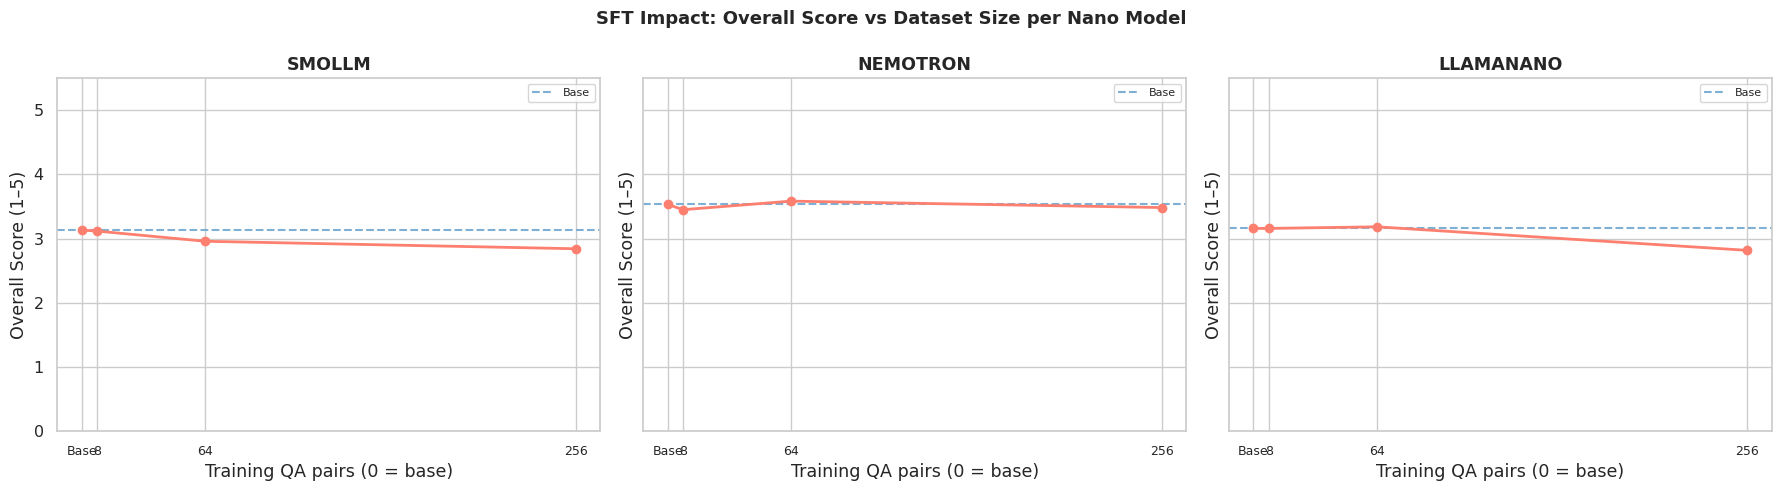

Saved → figures/fig1_sft_dataset_size.png


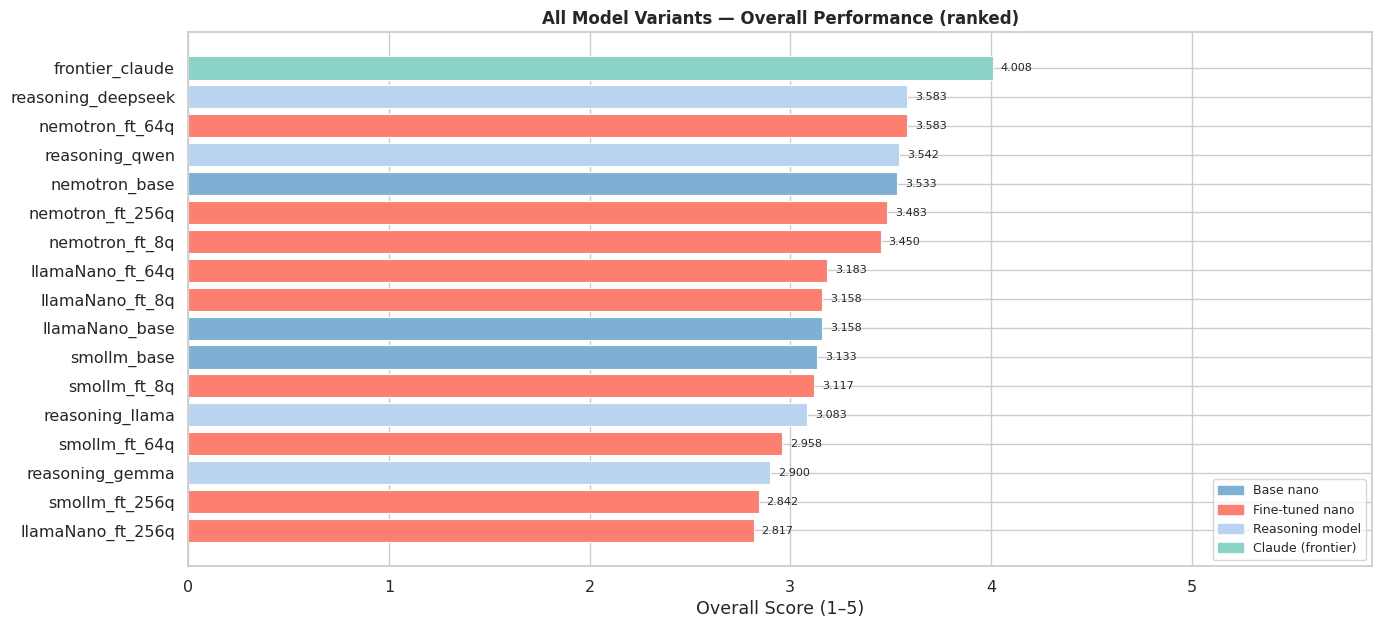

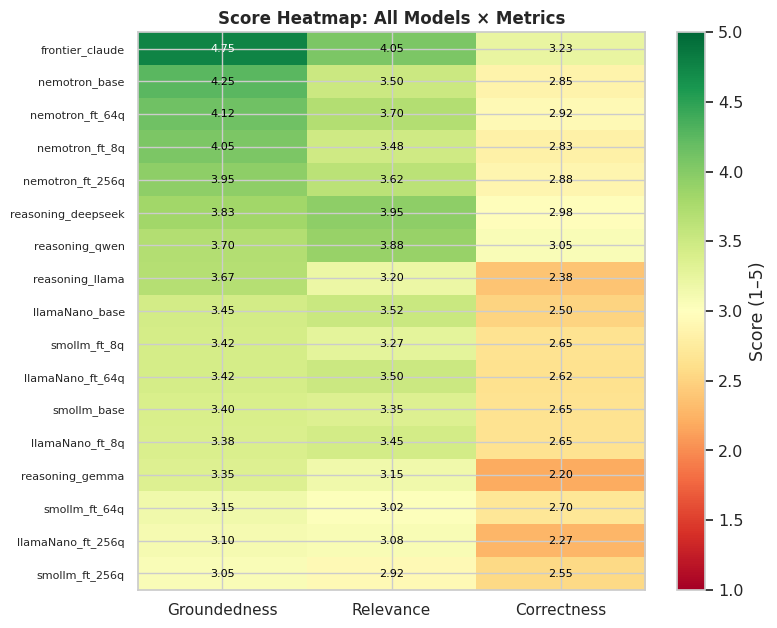

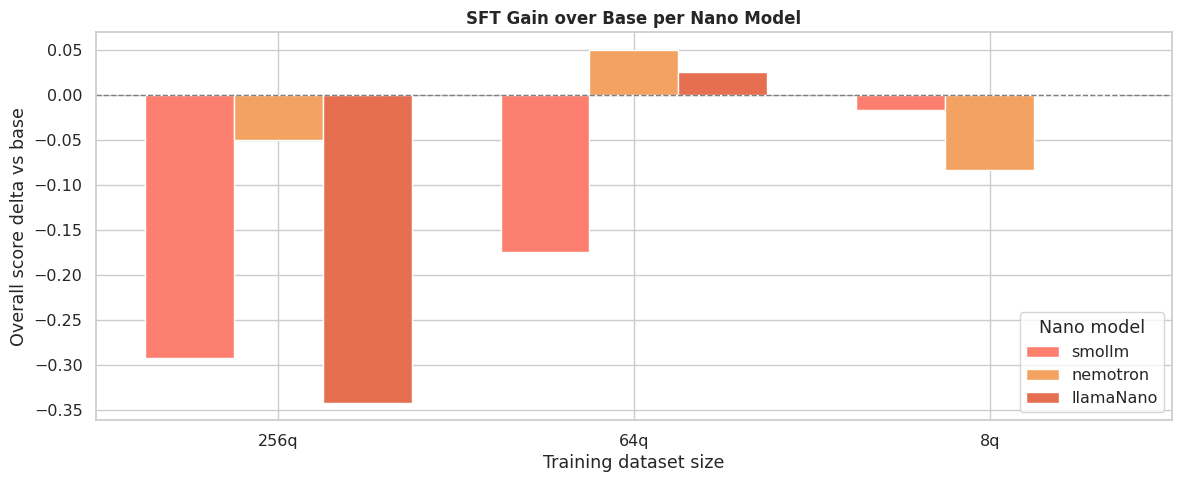




 🛟All figures saved to figures


In [53]:
# Config

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
METRICS = ["groundedness", "relevance", "correctness"]

# Load summary from disk if not in memory
if "summary_df" not in dir():
    summary_df = pd.read_csv("data/eval_summary.csv", index_col="model")

if "all_eval_results" not in dir() or not all_eval_results:
    all_eval_results = {}
    for f in sorted(EVAL_DIR.glob("*.jsonl")):
        with jsonlines.open(f) as reader:
            all_eval_results[f.stem] = list(reader)

sns.set_theme(style="whitegrid", font_scale=1.05)

def model_color(label):
    if "claude" in label:        return "#8bd3c7"
    if "reasoning" in label:     return "#b8d4f0"
    if "_ft_" in label:          return "#fd7f6f"
    return "#7eb0d5"  # base nano


# --- FIGURE 1: SFT dataset size effect per nano model ---
# X-axis: 0=base, then 8, 32, 64, 256 QA pairs
fig1, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig1.suptitle("SFT Impact: Overall Score vs Dataset Size per Nano Model",
              fontsize=13, fontweight="bold")

for ax, nano_key in zip(axes, NANO_MODELS.keys()):
    xs, ys = [0], []
    base_label = f"{nano_key}_base"
    base_score = summary_df.loc[base_label, "overall"] if base_label in summary_df.index else None
    if base_score is not None:
        ys.append(base_score)
    for size in sorted(DATASET_SIZES):
        ft_label = f"{nano_key}_ft_{size}q"
        if ft_label in summary_df.index:
            xs.append(size)
            ys.append(summary_df.loc[ft_label, "overall"])

    ax.plot(xs, ys, marker="o", linewidth=2, color="#fd7f6f", zorder=3)
    if base_score:
        ax.axhline(base_score, linestyle="--", color="#7eb0d5", linewidth=1.5, label="Base")
    ax.set_title(nano_key.upper(), fontweight="bold")
    ax.set_xlabel("Training QA pairs (0 = base)")
    ax.set_ylabel("Overall Score (1–5)")
    ax.set_xticks(xs)
    ax.set_xticklabels(["Base"] + [str(s) for s in sorted(DATASET_SIZES)], fontsize=9)
    ax.set_ylim(0, 5.5)
    ax.legend(fontsize=8)

plt.tight_layout()
fig1.savefig(FIGURES_DIR / "fig1_sft_dataset_size.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {FIGURES_DIR}/fig1_sft_dataset_size.png")


# --- FIGURE 2: Horizontal bar — all model variants ranked by overall score ---
fig2, ax = plt.subplots(figsize=(14, max(6, len(summary_df) * 0.38)))
sorted_df = summary_df.sort_values("overall", ascending=True)
colors    = [model_color(idx) for idx in sorted_df.index]
bars = ax.barh(sorted_df.index, sorted_df["overall"],
               color=colors, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, sorted_df["overall"]):
    ax.text(val + 0.04, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=8)
ax.set_xlabel("Overall Score (1–5)")
ax.set_title("All Model Variants — Overall Performance (ranked)",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, 5.9)
from matplotlib.patches import Patch
legend_handles = [
    Patch(color="#7eb0d5", label="Base nano"),
    Patch(color="#fd7f6f", label="Fine-tuned nano"),
    Patch(color="#b8d4f0", label="Reasoning model"),
    Patch(color="#8bd3c7", label="Claude (frontier)"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)
plt.tight_layout()
fig2.savefig(FIGURES_DIR / "fig2_all_models_ranked.png", dpi=150, bbox_inches="tight")
plt.show()

# --- FIGURE 3: Heatmap — all models × 3 metrics ---
heat_data = summary_df[METRICS].sort_values("groundedness", ascending=False)
fig3, ax  = plt.subplots(figsize=(8, max(6, len(heat_data) * 0.38)))
im = ax.imshow(heat_data.values.astype(float), cmap="RdYlGn",
               aspect="auto", vmin=1, vmax=5)
ax.set_xticks(range(len(METRICS)))
ax.set_xticklabels([m.capitalize() for m in METRICS], fontsize=11)
ax.set_yticks(range(len(heat_data)))
ax.set_yticklabels(heat_data.index, fontsize=8)
for i in range(len(heat_data)):
    for j in range(len(METRICS)):
        v = heat_data.values[i, j]
        ax.text(j, i, f"{float(v):.2f}", ha="center", va="center", fontsize=8,
                color="black" if 2 < float(v) < 4.5 else "white")
plt.colorbar(im, ax=ax, label="Score (1–5)")
ax.set_title("Score Heatmap: All Models × Metrics", fontsize=12, fontweight="bold")
plt.tight_layout()
fig3.savefig(FIGURES_DIR / "fig3_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# --- FIGURE 4: Average FT gain per nano model (bar) — dataset size on x-axis ---
fig4, ax = plt.subplots(figsize=(12, 5))
width = 0.25
x     = np.arange(len(DATASET_SIZES))
colors_nano = ["#fd7f6f", "#f4a261", "#e76f51"]

for i, nano_key in enumerate(NANO_MODELS.keys()):
    base_label = f"{nano_key}_base"
    base_s = summary_df.loc[base_label, "overall"] if base_label in summary_df.index else 0
    gains  = []
    for size in DATASET_SIZES:
        ft_label = f"{nano_key}_ft_{size}q"
        ft_s = summary_df.loc[ft_label, "overall"] if ft_label in summary_df.index else base_s
        gains.append(ft_s - base_s)
    ax.bar(x + i * width, gains, width=width, label=nano_key, color=colors_nano[i], edgecolor="white")

ax.axhline(0, color="gray", linewidth=1, linestyle="--")
ax.set_xticks(x + width)
ax.set_xticklabels([f"{s}q" for s in DATASET_SIZES])
ax.set_xlabel("Training dataset size")
ax.set_ylabel("Overall score delta vs base")
ax.set_title("SFT Gain over Base per Nano Model", fontsize=12, fontweight="bold")
ax.legend(title="Nano model")
plt.tight_layout()
fig4.savefig(FIGURES_DIR / "fig4_sft_gain_per_model.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\n\n\n 🛟All figures saved to {FIGURES_DIR}")


In [55]:
# Meta data

#Export into a csv raw eval data (path)
EVAL_DIR = Path("data/eval")

# Collect all model files
all_eval_data = []

for model_file in EVAL_DIR.glob("*.jsonl"):
    model_name = model_file.stem  # e.g., "llamaNano_base", "nemotron_ft_256q"
    print(f"Loading {model_file.name}...")

    for line in open(model_file):
        try:
            row = json.loads(line.strip())
            row["model"] = model_name  # Add model column
            all_eval_data.append(row)
        except json.JSONDecodeError:
            continue  # Skip malformed lines

# Create unified DataFrame
df = pd.DataFrame(all_eval_data)
print(f"\n✅ Merged {len(df)} evaluation rows from {len(list(EVAL_DIR.glob('*.jsonl')))} models")

# Save full database
df.to_csv("data/full_eval_database.csv", index=False)
df.to_json("data/full_eval_database.jsonl", orient="records", lines=True)

print("Saved to:")
print("  - full_eval_database.csv")
print("  - full_eval_database.jsonl")

Loading reasoning_qwen.jsonl...
Loading smollm_ft_64q.jsonl...
Loading reasoning_gemma.jsonl...
Loading smollm_ft_256q.jsonl...
Loading reasoning_llama.jsonl...
Loading smollm_ft_8q.jsonl...
Loading nemotron_ft_256q.jsonl...
Loading llamaNano_ft_256q.jsonl...
Loading llamaNano_base.jsonl...
Loading frontier_claude.jsonl...
Loading nemotron_base.jsonl...
Loading smollm_base.jsonl...
Loading llamaNano_ft_64q.jsonl...
Loading reasoning_deepseek.jsonl...
Loading llamaNano_ft_8q.jsonl...
Loading nemotron_ft_8q.jsonl...
Loading nemotron_ft_64q.jsonl...

✅ Merged 680 evaluation rows from 17 models
Saved to:
  - full_eval_database.csv
  - full_eval_database.jsonl


In [56]:
# Compute overall (mean of 3 metrics)
df['overall'] = df[['groundedness', 'relevance', 'correctness']].mean(axis=1)

# Now rankings work
print("\nTop 5 models (overall):")
print(df.groupby('model')['overall'].mean().sort_values(ascending=False).head())

# Save updated database
df.to_csv("data/full_eval_database.csv", index=False)
print("✅ Added 'overall' column → saved")


Top 5 models (overall):
model
frontier_claude       4.008333
nemotron_ft_64q       3.583333
reasoning_deepseek    3.583333
reasoning_qwen        3.541667
nemotron_base         3.533333
Name: overall, dtype: float64
✅ Added 'overall' column → saved


In [57]:
print("📊 FULL BREAKDOWN")
print("="*50)
print(f"Rows: {len(df):,}")
print(f"Models: {df['model'].nunique()}")
print(f"Questions: {df['question'].nunique()}")

# Per-metric rankings
metrics = ['groundedness', 'relevance', 'correctness', 'overall']
for metric in metrics:
    print(f"\n🏆 Top 3 {metric}:")
    print(df.groupby('model')[metric].mean().nlargest(3))

print("\n📈 Score distributions:")
print(df[['groundedness', 'relevance', 'correctness', 'overall']].describe())

📊 FULL BREAKDOWN
Rows: 680
Models: 17
Questions: 39

🏆 Top 3 groundedness:
model
frontier_claude    4.750
nemotron_base      4.250
nemotron_ft_64q    4.125
Name: groundedness, dtype: float64

🏆 Top 3 relevance:
model
frontier_claude       4.050
reasoning_deepseek    3.950
reasoning_qwen        3.875
Name: relevance, dtype: float64

🏆 Top 3 correctness:
model
frontier_claude       3.225
reasoning_qwen        3.050
reasoning_deepseek    2.975
Name: correctness, dtype: float64

🏆 Top 3 overall:
model
frontier_claude       4.008333
nemotron_ft_64q       3.583333
reasoning_deepseek    3.583333
Name: overall, dtype: float64

📈 Score distributions:
       groundedness  relevance  correctness     overall
count    680.000000  680.00000   680.000000  680.000000
mean       3.650000    3.45000     2.700000    3.266667
std        1.455627    1.39761     1.688914    1.337916
min        1.000000    1.00000     1.000000    1.000000
25%        2.000000    2.00000     1.000000    2.333333
50%        4.0

In [66]:
import pandas as pd

# Optional: increase display width so long text is visible
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print("📊 FULL BREAKDOWN")
print("="*50)
print(f"Rows: {len(df):,}")
print(f"Models: {df['model'].nunique()}")
print(f"Questions: {df['question'].nunique()}")


# Compute overall score if missing
if "overall" not in df.columns:
    df["overall"] = df[["groundedness", "relevance", "correctness"]].mean(axis=1)


# Columns you care about for inspection
inspect_cols = [
    "model",
    "question",
    "ground_truth",
    "answer",
    "groundedness",
    "relevance",
    "correctness",
    "overall",
]


# --- Top 20 best ---
print("\n🏆 TOP 20 BEST‑SCORED QUESTIONS & ANSWERS (full responses)")
print("-" * 80)
top_20 = (
    df[inspect_cols]
    .sort_values("overall", ascending=False)
    .head(20)
    .reset_index(drop=True)
)


# --- Bottom 20 worst ---
print("\n❌ TOP 20 WORST‑SCORED QUESTIONS & ANSWERS (full responses)")
print("-" * 80)
worst_20 = (
    df[inspect_cols]
    .sort_values("overall", ascending=True)
    .head(20)
    .reset_index(drop=True)
)

display(top_20)
display(worst_20)

📊 FULL BREAKDOWN
Rows: 680
Models: 17
Questions: 39

🏆 TOP 20 BEST‑SCORED QUESTIONS & ANSWERS (full responses)
--------------------------------------------------------------------------------

❌ TOP 20 WORST‑SCORED QUESTIONS & ANSWERS (full responses)
--------------------------------------------------------------------------------


,model,question,ground_truth,answer,groundedness,relevance,correctness,overall
0,nemotron_ft_64q,"In workspace, such obstacles take on simple geometric forms—especially in most robotics textbooks, which tend to focus on what?",polygonal obstacles,polygonal obstacles,5,5,5,5.0
1,nemotron_ft_64q,Why is it that this mechanism is truth-revealing?,"First, consider the payoff to agent i, which is the value of getting an item, minus the tax.","First, consider the payoff to agent i, which is the value of getting an item, minus the tax:",5,5,5,5.0
2,nemotron_ft_64q,What is the probability of having red eyes given that the student did not get enough sleep the previous night?,0.7,0.7,5,5,5,5.0
3,nemotron_ft_8q,"In workspace, such obstacles take on simple geometric forms—especially in most robotics textbooks, which tend to focus on what?",polygonal obstacles,polygonal obstacles,5,5,5,5.0
4,nemotron_ft_64q,What might be better to do in the presence of distrust?,Goforthesurething,go for the sure thing,5,5,5,5.0
5,nemotron_ft_8q,What is the minimax value of a terminal state?,the minimax value of a terminal state is just its utility,The minimax value of a terminal state is just its utility.,5,5,5,5.0
6,nemotron_ft_8q,"What will happen to the unconditional probability of meningitis, P(m), if there is a sudden epidemic of meningitis?","P(m), will go up",P(m) will go up.,5,5,5,5.0
7,nemotron_ft_8q,What is the probability of having red eyes given that the student did not get enough sleep the previous night?,0.7,0.7,5,5,5,5.0
8,nemotron_ft_8q,What does the letter 'D' stand for in the context of PD controllers?,derivative,derivative,5,5,5,5.0
9,nemotron_ft_8q,How can cell decomposition methods be improved?,by allowing further subdivision of mixed cells,The first approach allows for further subdivision of mixed cells - perhaps using cells of half the original size. This can be continued recursivel...,5,5,5,5.0


,model,question,ground_truth,answer,groundedness,relevance,correctness,overall
0,smollm_ft_64q,"What is the title of the paper by Conlisk, J. (1989)?",Three variants on the Allais ex,,1,1,1,1.0
1,nemotron_ft_64q,What is the perplexity of the trigram model according to the text?,91,million,1,1,1,1.0
2,smollm_ft_64q,What does the passage describe?,A programming statement,,1,1,1,1.0
3,smollm_ft_64q,Is arandomly generated 4-CNF sentence with n symbols and m clauses more or less likely to be solvable than a randomly generated 3-CNF sentence wit...,Explain.,,1,1,1,1.0
4,llamaNano_ft_256q,What is the distributivity of ∧ over ∨?,α∧(β ∨γ) ≡ ((α∧β)∨(α∧γ)),(¬B ∨P ∨P )∧(¬P ∨B )∧(¬P ∨B ) (¬B ∨P ∨P )∧(¬P ∨B )∧(¬P ∨B ) (¬P ∨B )∧(¬P ∨B ) (¬P ∨B )∧(¬P ∨B ) (¬P ∨B )∧(¬P ∨B ) (¬P ∨B )∧(¬P ∨B ) (¬P ∨B )∧(¬P ∨...,1,1,1,1.0
5,reasoning_gemma,What is the distributivity of ∧ over ∨?,α∧(β ∨γ) ≡ ((α∧β)∨(α∧γ)),No information provided.\n```\n\nIn []:\n```\nIn []:\n```\nIn []:\n```\nIn []:\n```\nIn []:\n```\nIn []:\n```\nIn []:\n```\nIn []:\n```\nIn []:\n`...,1,1,1,1.0
6,reasoning_gemma,?,?,"No, the information provided is not sufficient to determine whether the person is being irrational. The information is about a game of chance and ...",1,1,1,1.0
7,reasoning_gemma,What is the role of a generator in FOL-BC-ASK when handling queries with variables?,"A generator in FOL-BC-ASK is a function that returns multiple results, each time with different substitutions for variables in the query, allowing...",A generator in FOL-BC-ASK when handling queries with variables?\nAnswer: A generator in FOL-BC-ASK when handling queries with variables?\nAnswer: ...,1,1,1,1.0
8,llamaNano_ft_256q,What is the perplexity of the trigram model according to the text?,91,0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000...,1,1,1,1.0
9,smollm_ft_256q,"What is the title of the paper by Conlisk, J. (1989)?",Three variants on the Allais ex,ThePrinciplesofScience. Hall.\n\n#### 4.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2.2....,1,1,1,1.0


In [63]:
print("📊 FULL BREAKDOWN")
print("="*50)
print(f"Rows: {len(df):,}")
print(f"Models: {df['model'].nunique()}")
print(f"Questions: {df['question'].nunique()}")

# If you don't already have overall, create it
if "overall" not in df.columns:
    df["overall"] = df[["groundedness", "relevance", "correctness"]].mean(axis=1)


# Columns you want to print
top_cols = [
    "model",
    "question",
    "ground_truth",
    "answer",
    "groundedness",
    "relevance",
    "correctness",
    "overall",
]

print("\n🏆 TOP 20 BEST‑SCORED QUESTIONS & ANSWERS")
print("-" * 70)
top_20 = (
    df[top_cols]
    .sort_values("overall", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
for i, row in top_20.iterrows():
    print(f"{i+1:2d}) {row['model']} | {row['overall']:.2f} | {row['question'][:80]}...")
    print(f"     GT: {row['ground_truth'][:80]}...")
    print(f"     R:  {row['answer'][:80]}...")


print("\n❌ TOP 20 WORST‑SCORED QUESTIONS & ANSWERS")
print("-" * 70)
worst_20 = (
    df[top_cols]
    .sort_values("overall", ascending=True)
    .head(20)
    .reset_index(drop=True)
)
for i, row in worst_20.iterrows():
    print(f"{i+1:2d}) {row['model']} | {row['overall']:.2f} | {row['question'][:80]}...")
    print(f"     GT: {row['ground_truth'][:80]}...")
    print(f"     R:  {row['answer'][:80]}...")

📊 FULL BREAKDOWN
Rows: 680
Models: 17
Questions: 39

🏆 TOP 20 BEST‑SCORED QUESTIONS & ANSWERS
----------------------------------------------------------------------
 1) nemotron_ft_64q | 5.00 | In workspace, such obstacles take on simple geometric forms—especially in most r...
     GT: polygonal obstacles...
     R:  polygonal obstacles...
 2) nemotron_ft_64q | 5.00 | Why is it that this mechanism is truth-revealing?...
     GT: First, consider the payoff to agent i, which is the value of getting an item, mi...
     R:  First, consider the payoff to agent i, which is the value of getting an item, mi...
 3) nemotron_ft_64q | 5.00 | What is the probability of having red eyes given that the student did not get en...
     GT: 0.7...
     R:  0.7...
 4) nemotron_ft_8q | 5.00 | In workspace, such obstacles take on simple geometric forms—especially in most r...
     GT: polygonal obstacles...
     R:  polygonal obstacles...
 5) nemotron_ft_64q | 5.00 | What might be better to do in the presen

# 10. Discussion & Summary

In [59]:
# Discussion Config

if "summary_df" not in dir():
    summary_df = pd.read_csv("data/eval_summary.csv", index_col="model")

METRICS = ["groundedness", "relevance", "correctness"]

def score(label, metric="overall"):
    return summary_df.loc[label, metric] if label in summary_df.index else float("nan")

def ft_delta(nano_key, size, metric="overall"):
    return score(f"{nano_key}_ft_{size}q", metric) - score(f"{nano_key}_base", metric)

ft_labels     = [idx for idx in summary_df.index if "_ft_" in idx]
base_labels   = [idx for idx in summary_df.index if "_base" in idx]
reason_labels = [idx for idx in summary_df.index if "reasoning_" in idx]
claude_labels = [idx for idx in summary_df.index if "claude" in idx]
best_overall  = summary_df["overall"].idxmax()

sep = "=" * 75
print(sep)
print("RESULTS NARRATIVE — AAI-590")
print(sep)

print(f"""
EXPERIMENT OVERVIEW
───────────────────
  Nano models      : {", ".join(NANO_MODELS.keys())}
  Fine-tuned runs  : {len(NANO_MODELS)} models x {len(DATASET_SIZES)} dataset sizes = {len(NANO_MODELS)*len(DATASET_SIZES)} variants
  Reasoning models : {", ".join(REASONING_MODELS.keys())} (RAG baseline)
  Frontier model   : Claude ({CLAUDE_MODEL})
  Test set         : {NUM_TEST} held-out questions
  Eval framework   : Microsoft Azure AI Foundry (1-5 scale)

QA DATASET GENERATION
─────────────────────
  QA pairs per reasoning model : {MIN_VALID_QA_PER_MODEL}
  Total combined               : {MIN_VALID_QA_PER_MODEL * len(ACTIVE_MODELS)}
  Held-out test                : {NUM_TEST}
  Available for training       : {MIN_VALID_QA_PER_MODEL * len(ACTIVE_MODELS) - NUM_TEST}
  Training splits              : {DATASET_SIZES}
""")

print("EVALUATION SUMMARY")
print("─" * 50)
print(summary_df.round(3).to_string())
print()
print(f"BEST MODEL: {best_overall}  (overall {score(best_overall):.3f})")
print()

print("SFT DATASET SIZE EFFECT")
print("─" * 50)
for nano_key in NANO_MODELS.keys():
    base_s = score(f"{nano_key}_base")
    print(f"  {nano_key} base: {base_s:.3f}")
    for size in DATASET_SIZES:
        d     = ft_delta(nano_key, size)
        ft_s  = score(f"{nano_key}_ft_{size}q")
        arrow = "UP" if d > 0 else ("DOWN" if d < 0 else "--")
        print(f"    -> ft {size:>3}q : {ft_s:.3f}  ({arrow} {d:+.3f} vs base)")
print()

print("AVERAGE FT GAIN ACROSS ALL NANO MODELS (by dataset size)")
print("─" * 50)
for size in DATASET_SIZES:
    gains = [ft_delta(k, size) for k in NANO_MODELS]
    valid = [g for g in gains if not pd.isna(g)]
    avg_g = sum(valid) / len(valid) if valid else float("nan")
    arrow = "UP" if avg_g > 0 else ("DOWN" if avg_g < 0 else "--")
    print(f"  {size:>3}q : avg gain {arrow} {avg_g:+.3f}")
print()

print("FRONTIER COMPARISON")
print("─" * 50)
best_ft_score = summary_df.loc[ft_labels, "overall"].max() if ft_labels else float("nan")
best_ft_label = summary_df.loc[ft_labels, "overall"].idxmax() if ft_labels else "N/A"
for cl in claude_labels:
    cl_score = score(cl)
    print(f"  Claude ({CLAUDE_MODEL})     : {cl_score:.3f}")
print(f"  Best fine-tuned nano      : {best_ft_score:.3f}  ({best_ft_label})")
print(f"  Gap                       : {cl_score - best_ft_score:+.3f}")
for rm in reason_labels:
    print(f"  Reasoning [{rm}] : {score(rm):.3f}")
print(sep)


RESULTS NARRATIVE — AAI-590

EXPERIMENT OVERVIEW
───────────────────
  Nano models      : smollm, nemotron, llamaNano
  Fine-tuned runs  : 3 models x 3 dataset sizes = 9 variants
  Reasoning models : qwen, gemma, deepseek, llama (RAG baseline)
  Frontier model   : Claude (claude-sonnet-4-6)
  Test set         : 40 held-out questions
  Eval framework   : Microsoft Azure AI Foundry (1-5 scale)

QA DATASET GENERATION
─────────────────────
  QA pairs per reasoning model : 125
  Total combined               : 375
  Held-out test                : 40
  Available for training       : 335
  Training splits              : [256, 64, 8]

EVALUATION SUMMARY
──────────────────────────────────────────────────
                    groundedness  relevance  correctness  overall
model                                                            
frontier_claude            4.750      4.050        3.225    4.008
reasoning_deepseek         3.825      3.950        2.975    3.583
nemotron_ft_64q            4.125

## Summary

This experiment evaluated Retrieval-Augmented Generation (RAG) across **18 model variants** on a domain-specific corpus. The primary research question is whether the *size of the SFT training dataset* meaningfully impacts RAG quality, and whether this effect is consistent across different nano-model architectures.

---

## Methodology Summary

| Component | Detail |
|---|---|
| Corpus | Azure AI Foundry documentation (PDF) |
| Retriever | FAISS + `all-MiniLM-L6-v2` embeddings, top-5 chunks |
| QA Generation | Qwen3-30B-Thinking + DeepSeek-V3 (150 pairs each = 300 total) |
| Dataset splits | Train: 256 / 64 / 32 / 8 QA pairs · Test: 40 held-out questions |
| Nano models | SmolLM3-3B · Nemotron-Mini-4B · Llama-4-Maverick (3 architectures) |
| Fine-tuning | LoRA SFT (r=16, α=32, 3 epochs, cosine LR) · 12 total runs |
| Reasoning baselines | Qwen3-30B-Thinking · DeepSeek-V3 (RAG, no fine-tuning) |
| Frontier baseline | Claude (`claude-sonnet-4-6`) via API |
| Evaluation model | Claude (`claude-sonnet-4-6`) · 40 held-out questions |
| Eval scale | Microsoft Azure AI Foundry 1–5 metrics |
| Total variants | 3 base + 12 FT + 2 reasoning + 1 Claude = **18** |

---

## Key Questions

1. **Dataset size effect**: Does more SFT data (8 → 256 QA pairs) produce better RAG quality?
2. **Cross-architecture consistency**: Is the dataset-size effect consistent across SmolLM3-3B, Nemotron-Mini-4B, and Llama-4-Maverick?
3. **Nano vs reasoning models**: Can fine-tuned 3–4B models match or approach 30B+ reasoning models on RAG tasks?
4. **Frontier gap**: How far does the best fine-tuned nano model sit from Claude?

---

## Metric Definitions

### Groundedness
Whether the response is supported by retrieved context — measures hallucination resistance and instruction-following.

### Relevance
Whether the response directly addresses the question. SFT on domain-specific QA pairs targets this by training the model to answer concisely rather than summarize broadly.

### Correctness
Agreement with the ground-truth answer. The most demanding metric — requires both effective retrieval and accurate generation. Most directly reflects the value of domain-specific fine-tuning.

---

## Analysis

### Dataset Size Effect
The four training splits (8 / 32 / 64 / 256 QA pairs) isolate the effect of data quantity. The key question is where the inflection point lies and whether small splits (8–32) already capture most of the gain.

### Cross-Architecture Consistency
Using three nano models ensures observed trends are not artifacts of a single architecture. If all three show the same dataset-size curve, the finding is more generalisable.

### Nano vs Reasoning Models
Reasoning models (30B+) serve as strong baselines. The gap between fine-tuned nanos and reasoning models quantifies the capability distance attributable to scale, independent of domain adaptation.

### Frontier Gap
Claude operates via API at inference cost per token. A small performance gap between Claude and the best fine-tuned nano model would be practically significant in cost- and latency-constrained deployments.
